# KMeans Clustering Using the eICU Variables

This notebook fits and compares KMeans models using the standardized eICU clinical variables.

The following candidate solutions are evaluated :
- $k = 2$
- $k = 3$
- $k = 4$
- $k = 5$
- $k = 6$

The comparison uses :
- Within-cluster sum of squares
- Average silhouette score
- Cluster size and percentage
- Small-cluster warnings
- Stability across different random seeds
- Cluster center separation
- PCA Visulaizations
- Standardized Cluster-Center Heatmaps

The preliminary number of clusters is selected using several forms of evidence rather than one numerical metric.

### Import Required Libraries

In [1]:
from pathlib import Path
from itertools import combinations
import json
import warnings

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    pairwise_distances,
    silhouette_samples,
    silhouette_score,
)


# Improve table display
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 180)

# Plot appearance
sns.set_theme(style="whitegrid")

# Hide unimportant warnings
warnings.filterwarnings("ignore")

print("All required libraries were imported successfully.")

All required libraries were imported successfully.


#### Explanation :
This cell imports the libraries required to:

- Load the standardized eICU data.
- Fit K-Means models.
- Calculate clustering metrics.
- Test stability across random seeds.
- Perform PCA.
- Create and save plots.
- Save fitted K-Means models.

### Locate the Project Root Folder

In [2]:
CURRENT_DIR = Path.cwd().resolve()

if (
    (CURRENT_DIR / "data").exists()
    and (CURRENT_DIR / "notebooks").exists()
):
    ROOT_DIR = CURRENT_DIR

elif (
    CURRENT_DIR.name == "module_2"
    and CURRENT_DIR.parent.name == "notebooks"
):
    ROOT_DIR = CURRENT_DIR.parents[1]

elif CURRENT_DIR.name == "notebooks":
    ROOT_DIR = CURRENT_DIR.parent

else:
    raise FileNotFoundError(
        "The project root folder could not be identified.\n"
        "Run the notebook from the project root, notebooks folder, "
        "or notebooks/module_2 folder."
    )


print("=" * 100)
print("PROJECT ROOT")
print("=" * 100)
print(f"Current directory : {CURRENT_DIR}")
print(f"Project root      : {ROOT_DIR}")
print("=" * 100)

PROJECT ROOT
Current directory : C:\Users\samsa\Documents\Capstone Project\Project\notebooks\module_2
Project root      : C:\Users\samsa\Documents\Capstone Project\Project


#### Explanation :
This code automatically finds the main project folder. It allows the notebook to run from the project root or from the notebook folders.

### Define the Input and Output Folders

In [3]:
# ---------------------------------------------------------
# Input folders
# ---------------------------------------------------------
DATA_DIR = ROOT_DIR / "data"

ANALYTIC_RESULTS_DIR = (
    ROOT_DIR
    / "results"
    / "analytic_dataset"
)


# ---------------------------------------------------------
# Task 6 output folders
# ---------------------------------------------------------
RESULTS_DIR = (
    ROOT_DIR
    / "results"
    / "kmeans_eicu"
)

PLOTS_DIR = (
    ROOT_DIR
    / "plots"
    / "kmeans_eicu"
)


# Result subfolders
ASSIGNMENTS_DIR = RESULTS_DIR / "assignments"
CENTERS_DIR = RESULTS_DIR / "cluster_centers"
MODELS_DIR = RESULTS_DIR / "models"
TOP_FEATURES_DIR = RESULTS_DIR / "top_features"


# Plot subfolders
MODEL_METRICS_PLOT_DIR = (
    PLOTS_DIR
    / "model_metrics"
)

SILHOUETTE_PLOT_DIR = (
    PLOTS_DIR
    / "silhouette"
)

CLUSTER_SIZE_PLOT_DIR = (
    PLOTS_DIR
    / "cluster_sizes"
)

STABILITY_PLOT_DIR = (
    PLOTS_DIR
    / "stability"
)

PCA_PLOT_DIR = (
    PLOTS_DIR
    / "pca_clusters"
)

CENTER_PLOT_DIR = (
    PLOTS_DIR
    / "cluster_centers"
)


# Create all required folders
folders_to_create = [
    RESULTS_DIR,
    PLOTS_DIR,
    ASSIGNMENTS_DIR,
    CENTERS_DIR,
    MODELS_DIR,
    TOP_FEATURES_DIR,
    MODEL_METRICS_PLOT_DIR,
    SILHOUETTE_PLOT_DIR,
    CLUSTER_SIZE_PLOT_DIR,
    STABILITY_PLOT_DIR,
    PCA_PLOT_DIR,
    CENTER_PLOT_DIR,
]


for folder in folders_to_create:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )


print("=" * 100)
print("TASK 6 OUTPUT FOLDERS")
print("=" * 100)
print(f"Results folder : {RESULTS_DIR}")
print(f"Plots folder   : {PLOTS_DIR}")
print("=" * 100)

TASK 6 OUTPUT FOLDERS
Results folder : C:\Users\samsa\Documents\Capstone Project\Project\results\kmeans_eicu
Plots folder   : C:\Users\samsa\Documents\Capstone Project\Project\plots\kmeans_eicu


#### Explanation :
Results are stored in :
```
results/kmeans_eicu/
```
Plots are stored in :
```
plots/kmeans_eicu/
```

Separate subfolders are created for assignments, models, cluster centers, silhouette plots, PCA plots and other outputs.

### Define the Input File Paths

In [4]:
STANDARDIZED_MATRIX_PATH = (
    DATA_DIR
    / "clustering_matrix_standardized.csv"
)

ANALYTIC_DATASET_PATH = (
    DATA_DIR
    / "analytic_dataset.csv"
)

ROW_IDS_PATH = (
    ANALYTIC_RESULTS_DIR
    / "clustering_row_ids.csv"
)


required_input_files = [
    STANDARDIZED_MATRIX_PATH,
    ANALYTIC_DATASET_PATH,
    ROW_IDS_PATH,
]


for file_path in required_input_files:

    if not file_path.exists():
        raise FileNotFoundError(
            f"Required input file was not found:\n{file_path}"
        )


print("All required input files were found.")

All required input files were found.


#### Explanation :
The notebook requires three files:
```
data/clustering_matrix_standardized.csv
data/analytic_dataset.csv
results/analytic_dataset/clustering_row_ids.csv
```
The standardized matrix is used for K-Means. The analytic dataset contains understandable clinical values. The row-ID file connects the standardized rows to ICU stay identifiers.

### Define the $29$ expected clustering variables

In [5]:
ID_COLUMN = "patientunitstayid"


FEATURES = [
    # Demographics and medical history
    "age",
    "sex_female",
    "elixhauser_count",

    # Vital signs and neurological status
    "heart_rate",
    "respiratory_rate",
    "systolic_blood_pressure",
    "temperature",
    "oxygen_saturation",
    "gcs",

    # Inflammatory markers
    "wbc",
    "band_count",
    "esr",
    "crp",

    # Organ dysfunction markers
    "ast",
    "alt",
    "total_bilirubin",
    "bun",
    "creatinine",
    "inr",
    "pao2",
    "platelets",
    "troponin",

    # Other laboratory measurements
    "glucose",
    "sodium",
    "hemoglobin",
    "chloride",
    "bicarbonate",
    "lactate",
    "albumin",
]


assert len(FEATURES) == 29

print(
    f"Number of expected clustering variables: "
    f"{len(FEATURES)}"
)

Number of expected clustering variables: 29


#### Explanation :
These are the exact $29$ features expected in the standardized matrix. The ICU stay identifier is not included because it must not affect Euclidean distance.

### Define the KMeans Settings

In [6]:
# Candidate values required by the instructions
K_VALUES = [
    2,
    3,
    4,
    5,
    6,
]


# Fixed seed for the main K-Means models
PRIMARY_RANDOM_SEED = 42


# Alternative seeds used for stability testing
STABILITY_RANDOM_SEEDS = [
    0,
    10,
    21,
    42,
    100,
]


# Explicit number of K-Means initializations
N_INIT = 10


# Maximum K-Means iterations
MAX_ITERATIONS = 300


# Convergence tolerance
TOLERANCE = 1e-4


# Fixed sample used for silhouette calculations
SILHOUETTE_SAMPLE_SIZE = 10_000


# Fixed sample used for PCA scatter plots
PCA_PLOT_SAMPLE_SIZE = 10_000


# Cluster-size warning thresholds
SMALL_CLUSTER_PERCENT = 5.0
EXTREMELY_SMALL_CLUSTER_PERCENT = 1.0


# Number of important variables shown per cluster center
TOP_FEATURES_PER_CLUSTER = 5


print("K-Means settings were defined.")

K-Means settings were defined.


#### Explanation :
The main models use :
```
Initialization: K-Means++
Primary seed: 42
n_init: 10
Candidate k values: 2, 3, 4, 5, 6
```

A cluster containing less than $5\%$ of the cohort is flagged as small. A cluster containing less than $1\%$ is flagged as extremely small.

### Save the Analysis Settings

In [7]:
kmeans_settings = {
    "candidate_k_values": K_VALUES,
    "primary_random_seed": PRIMARY_RANDOM_SEED,
    "stability_random_seeds": STABILITY_RANDOM_SEEDS,
    "initialization": "k-means++",
    "n_init": N_INIT,
    "maximum_iterations": MAX_ITERATIONS,
    "tolerance": TOLERANCE,
    "silhouette_sample_size": SILHOUETTE_SAMPLE_SIZE,
    "pca_plot_sample_size": PCA_PLOT_SAMPLE_SIZE,
    "small_cluster_percent": SMALL_CLUSTER_PERCENT,
    "extremely_small_cluster_percent": (
        EXTREMELY_SMALL_CLUSTER_PERCENT
    ),
    "number_of_features": len(FEATURES),
    "features": FEATURES,
}


with open(
    RESULTS_DIR / "kmeans_settings.json",
    "w",
    encoding="utf-8",
) as settings_file:

    json.dump(
        kmeans_settings,
        settings_file,
        indent=4,
    )


print(
    "K-Means settings were saved to "
    "results/kmeans_eicu/kmeans_settings.json"
)

K-Means settings were saved to results/kmeans_eicu/kmeans_settings.json


#### Explanation :
The settings file documents exactly how the models were fitted. This makes the analysis reproducible.

### Load the Standardized Clustering Matrix

In [8]:
standardized_data = pd.read_csv(
    STANDARDIZED_MATRIX_PATH
)


print("=" * 80)
print("STANDARDIZED MATRIX")
print("=" * 80)
print(f"Rows    : {standardized_data.shape[0]:,}")
print(f"Columns : {standardized_data.shape[1]}")
print("=" * 80)

standardized_data.head()

STANDARDIZED MATRIX
Rows    : 116,573
Columns : 29


,age,sex_female,elixhauser_count,heart_rate,respiratory_rate,systolic_blood_pressure,temperature,oxygen_saturation,gcs,wbc,band_count,esr,crp,ast,alt,total_bilirubin,bun,creatinine,inr,pao2,platelets,troponin,glucose,sodium,hemoglobin,chloride,bicarbonate,lactate,albumin
0,0.368812,1.097166,1.936710,2.409401,-0.057298,-0.591398,0.050328,-4.643280,0.431245,-0.181052,0.017823,0.017606,-0.000881,0.580762,0.378509,2.218605,0.294782,0.615982,0.734664,-0.123302,0.270812,-0.206270,-0.080084,0.124655,0.897599,-0.344348,0.339436,-0.120889,0.450996
1,0.247393,-0.911439,0.132699,0.077830,0.842715,-1.627261,0.050328,0.786594,0.720775,0.506748,0.017823,0.017606,-0.000881,-0.529803,-0.532930,-0.683523,0.550692,1.033472,-0.186884,-0.123302,0.480637,-0.206270,0.505272,-0.622517,-0.899290,0.100058,-0.905237,-0.712126,-1.178083
2,0.429522,-0.911439,0.132699,-0.200275,1.019778,0.612619,0.050328,-0.625027,0.720775,1.714527,0.017823,0.017606,-0.000881,-1.095936,-0.669273,-0.911241,-0.402046,-0.570639,-0.186884,-1.185516,1.765750,-0.206270,0.159825,-0.622517,-0.285718,-1.085023,1.050678,-0.120889,-0.770814
3,0.793779,1.097166,0.930986,0.363388,-0.127728,-0.853977,0.050328,0.563396,0.431245,0.307069,0.017823,0.017606,-0.000881,-0.635576,-0.903382,-0.471523,-1.201306,-0.914364,-0.186884,-2.052172,2.165688,-0.487723,0.177378,1.245412,0.152547,0.396328,0.161625,1.762697,-2.603528
4,1.097327,-0.911439,-1.231982,1.427913,2.638893,-0.260939,0.050328,-0.979026,-0.726872,2.687550,0.803390,0.017606,-0.000881,-0.177617,-0.141024,-0.197335,0.502871,0.312627,-0.186884,-1.388729,0.166489,0.216432,0.177378,-0.996102,-1.206076,-0.492483,-1.438668,-0.555195,0.043726


#### Explanation :
This is the matrix used to fit KMeans. It should contain $29$ standardized variables and no ICU stay identifier.

### Load the Interpretable Analytic Dataset

In [9]:
analytic_data = pd.read_csv(
    ANALYTIC_DATASET_PATH
)


print("=" * 80)
print("ANALYTIC DATASET")
print("=" * 80)
print(f"Rows    : {analytic_data.shape[0]:,}")
print(f"Columns : {analytic_data.shape[1]}")
print("=" * 80)

analytic_data.head()

ANALYTIC DATASET
Rows    : 116,573
Columns : 30


,patientunitstayid,age,sex_female,elixhauser_count,heart_rate,respiratory_rate,systolic_blood_pressure,temperature,oxygen_saturation,gcs,wbc,band_count,esr,crp,ast,alt,total_bilirubin,bun,creatinine,inr,pao2,platelets,troponin,glucose,sodium,hemoglobin,chloride,bicarbonate,lactate,albumin
0,141168,70.0,1.0,4.0,125.052830,19.008403,108.500000,37.119459,86.741935,14.0,9.8,7.8,31.0,9.1,59.0,40.0,2.60,26.0,1.95,1.7,103.0,209.0,0.19,131.0,139.0,13.0,102.0,26.0,1.7,3.1
1,141194,68.0,0.0,1.0,86.860627,23.193662,88.896552,37.119459,98.589474,15.0,14.1,7.8,31.0,9.1,24.0,20.0,0.40,31.0,2.51,1.3,103.0,233.0,0.19,165.0,135.0,8.9,105.0,19.0,1.3,2.3
2,141196,71.0,0.0,1.0,82.305147,24.114815,131.285714,37.119459,95.509434,15.0,26.2,7.8,31.0,9.1,15.0,18.0,0.30,16.0,0.80,1.3,70.0,453.0,0.19,144.0,135.0,10.3,97.0,30.0,1.7,2.5
3,141203,77.0,1.0,2.0,91.538194,18.713208,103.530769,37.119459,98.102473,14.0,12.7,7.8,31.0,9.1,22.0,15.0,0.50,9.0,0.56,1.3,51.0,557.0,0.02,145.0,145.0,11.3,107.0,25.0,3.5,1.6
4,141227,82.0,0.0,0.0,108.975610,34.344948,114.753846,37.119459,94.737037,10.0,42.7,10.0,31.0,9.1,32.0,27.0,0.64,30.0,1.60,1.3,65.0,198.0,0.50,145.0,133.0,8.2,101.0,16.0,1.4,2.9


#### Explanation :
The analytic dataset contains the ICU identifier and variables in their clinical units. It is not used to fit KMeans but it helps check whether candidate cluster solutions are understandable.

### Load the ICU Stay Identifiers

In [10]:
row_ids = pd.read_csv(
    ROW_IDS_PATH
)


print("=" * 80)
print("ROW IDENTIFIERS")
print("=" * 80)
print(f"Rows    : {row_ids.shape[0]:,}")
print(f"Columns : {row_ids.shape[1]}")
print("=" * 80)

row_ids.head()

ROW IDENTIFIERS
Rows    : 116,573
Columns : 1


,patientunitstayid
0,141168
1,141194
2,141196
3,141203
4,141227


#### Explanation :
The row-ID file connects each row in the standardized matrix to its ICU stay identifier.

### Check the Input Datasets

In [11]:
# ---------------------------------------------------------
# Check that files are not empty
# ---------------------------------------------------------
assert not standardized_data.empty, (
    "The standardized matrix is empty."
)

assert not analytic_data.empty, (
    "The analytic dataset is empty."
)

assert not row_ids.empty, (
    "The row-ID table is empty."
)


# ---------------------------------------------------------
# Check the feature columns
# ---------------------------------------------------------
missing_standardized_features = [
    feature
    for feature in FEATURES
    if feature not in standardized_data.columns
]

extra_standardized_columns = [
    column
    for column in standardized_data.columns
    if column not in FEATURES
]


if missing_standardized_features:

    raise ValueError(
        "The standardized matrix is missing these variables:\n"
        f"{missing_standardized_features}"
    )


if extra_standardized_columns:

    raise ValueError(
        "The standardized matrix contains unexpected columns:\n"
        f"{extra_standardized_columns}"
    )


# Put the standardized variables in the expected order
standardized_data = standardized_data[
    FEATURES
].copy()


# Check the analytic dataset
missing_analytic_columns = [
    column
    for column in [
        ID_COLUMN,
        *FEATURES,
    ]
    if column not in analytic_data.columns
]


if missing_analytic_columns:

    raise ValueError(
        "The analytic dataset is missing these columns:\n"
        f"{missing_analytic_columns}"
    )


# Check the row-ID table
if ID_COLUMN not in row_ids.columns:

    raise ValueError(
        f"{ID_COLUMN} is missing from the row-ID file."
    )


# ---------------------------------------------------------
# Check row counts
# ---------------------------------------------------------
assert len(standardized_data) == len(analytic_data), (
    "The standardized and analytic datasets have different row counts."
)

assert len(standardized_data) == len(row_ids), (
    "The standardized matrix and row-ID file have different row counts."
)


# ---------------------------------------------------------
# Check identifier order
# ---------------------------------------------------------
analytic_ids = (
    analytic_data[ID_COLUMN]
    .reset_index(drop=True)
)

saved_row_ids = (
    row_ids[ID_COLUMN]
    .reset_index(drop=True)
)


assert analytic_ids.equals(saved_row_ids), (
    "The ICU identifiers do not have the same row order."
)


# ---------------------------------------------------------
# Check missing and infinite values
# ---------------------------------------------------------
assert not standardized_data.isna().any().any(), (
    "The standardized matrix contains missing values."
)

assert np.isfinite(
    standardized_data.to_numpy()
).all(), (
    "The standardized matrix contains infinite values."
)


# ---------------------------------------------------------
# Check identifier uniqueness
# ---------------------------------------------------------
assert row_ids[ID_COLUMN].is_unique, (
    "The row-ID file contains duplicate ICU stay identifiers."
)


print("All input dataset checks passed successfully.")

All input dataset checks passed successfully.


#### Explanation :
This cell confirms :
- All $29$ variables are present.
- There are no additional columns in the standardized matrix.
- Row counts match.
- ICU stay identifiers are aligned.
- There are no missing or infinite values.
- ICU stay identifiers are unique.

### Check the Standardized Means and Standard Deviations

In [12]:
input_standardization_check = pd.DataFrame(
    {
        "variable": FEATURES,
        "mean": standardized_data.mean().values,
        "standard_deviation": (
            standardized_data.std(
                ddof=0
            ).values
        ),
    }
)


input_standardization_check.to_csv(
    RESULTS_DIR
    / "input_standardization_check.csv",
    index=False,
)


input_standardization_check

,variable,mean,standard_deviation
0,age,6.436594e-17,1.0
1,sex_female,-5.071256e-17,1.0
2,elixhauser_count,-3.900966e-18,1.0
3,heart_rate,-1.628653e-16,1.0
4,respiratory_rate,1.275616e-15,1.0
5,systolic_blood_pressure,-2.301570e-16,1.0
6,temperature,1.026393e-14,1.0
7,oxygen_saturation,-1.565263e-15,1.0
8,gcs,-2.360085e-16,1.0
9,wbc,7.285055e-16,1.0


#### Explanation :
Each feature should have a mean close to $0$ and a standard deviation close to $1$. This confirms that the matrix is suitable for Euclidean-distance clustering.

### Prepare the Numerical Matrix

In [13]:
X = standardized_data.to_numpy(
    dtype=np.float64
)


NUMBER_OF_OBSERVATIONS = X.shape[0]
NUMBER_OF_FEATURES = X.shape[1]


print("=" * 80)
print("K-MEANS INPUT MATRIX")
print("=" * 80)
print(f"ICU stays : {NUMBER_OF_OBSERVATIONS:,}")
print(f"Features  : {NUMBER_OF_FEATURES}")
print("=" * 80)

K-MEANS INPUT MATRIX
ICU stays : 116,573
Features  : 29


#### Explanation :
`X` is the numerical matrix used by scikit-learn. It contains all eligible ICU stays and all $29$ standardized variables.

### Create a Fixed Silhouette Sample

In [14]:
sample_generator = np.random.default_rng(
    PRIMARY_RANDOM_SEED
)


actual_silhouette_sample_size = min(
    SILHOUETTE_SAMPLE_SIZE,
    NUMBER_OF_OBSERVATIONS,
)


silhouette_indices = sample_generator.choice(
    NUMBER_OF_OBSERVATIONS,
    size=actual_silhouette_sample_size,
    replace=False,
)


X_silhouette = X[
    silhouette_indices
]


silhouette_sample_ids = (
    row_ids.iloc[
        silhouette_indices
    ]
    .copy()
    .reset_index(drop=True)
)


silhouette_sample_ids[
    "original_row_index"
] = silhouette_indices


silhouette_sample_ids.to_csv(
    RESULTS_DIR
    / "silhouette_sample_ids.csv",
    index=False,
)


print(
    f"Silhouette sample size: "
    f"{actual_silhouette_sample_size:,}"
)

Silhouette sample size: 10,000


#### Explanation :
Silhouette calculations can be expensive for a large dataset. A fixed sample of upto $10000$ ICU stays is used.

The same sample is used for every value of `k`, making the silhouette scores comparable and reproducible.

KMeans itself is still fitted on the complete standardized dataset.

### Create a Fixed PCA Plotting Sample

In [15]:
pca_sample_generator = np.random.default_rng(
    PRIMARY_RANDOM_SEED
)


actual_pca_sample_size = min(
    PCA_PLOT_SAMPLE_SIZE,
    NUMBER_OF_OBSERVATIONS,
)


pca_plot_indices = pca_sample_generator.choice(
    NUMBER_OF_OBSERVATIONS,
    size=actual_pca_sample_size,
    replace=False,
)


print(
    f"PCA plotting sample size: "
    f"{actual_pca_sample_size:,}"
)

PCA plotting sample size: 10,000


#### Explanation :
A fixed sample is used for the PCA scatter plots so the plots remain readable and reproducible.

### Create a Function for Cluster-Size Summaries

In [16]:
def summarize_cluster_sizes(
    cluster_labels,
    number_of_clusters,
):
    """
    Calculate cluster counts, percentages, and size warnings.
    """

    total_observations = len(
        cluster_labels
    )


    cluster_counts = (
        pd.Series(
            cluster_labels
        )
        .value_counts()
        .reindex(
            range(
                number_of_clusters
            ),
            fill_value=0,
        )
        .sort_index()
    )


    cluster_size_table = pd.DataFrame(
        {
            "cluster": cluster_counts.index,
            "observation_count": (
                cluster_counts.values
            ),
        }
    )


    cluster_size_table[
        "observation_percent"
    ] = (
        cluster_size_table[
            "observation_count"
        ]
        / total_observations
        * 100
    )


    cluster_size_table[
        "small_cluster"
    ] = (
        cluster_size_table[
            "observation_percent"
        ]
        < SMALL_CLUSTER_PERCENT
    )


    cluster_size_table[
        "extremely_small_cluster"
    ] = (
        cluster_size_table[
            "observation_percent"
        ]
        < EXTREMELY_SMALL_CLUSTER_PERCENT
    )


    return cluster_size_table

#### Explanation :
This function calculates :
- Number of observations in every cluster.
- Percentage of the complete cohort.
- Whether a cluster is smaller than $5\%$.
- Whether a cluster is smaller than $1\%$.

### Create a Function for Center Separation

In [17]:
def calculate_center_separation(
    cluster_centers,
):
    """
    Calculate distances between the standardized cluster centers.
    """

    center_distance_matrix = pairwise_distances(
        cluster_centers,
        metric="euclidean",
    )


    upper_triangle_values = (
        center_distance_matrix[
            np.triu_indices(
                len(cluster_centers),
                k=1,
            )
        ]
    )


    return {
        "minimum_center_distance": float(
            upper_triangle_values.min()
        ),
        "mean_center_distance": float(
            upper_triangle_values.mean()
        ),
        "maximum_center_distance": float(
            upper_triangle_values.max()
        ),
    }

#### Explanation :
This calculates Euclidean distances between cluster centers.

Larger distances generally mean that the centers represent more distinct standardized profiles. This is supporting evidence and should not replace silhouette or stability analysis.

### Create a Function for the Top Distinguishing Variables

In [18]:
def identify_top_center_features(
    cluster_centers,
    number_of_clusters,
):
    """
    Identify variables with the largest absolute standardized
    center values for every cluster.
    """

    top_feature_rows = []


    for cluster_number in range(
        number_of_clusters
    ):

        center_values = (
            cluster_centers[
                cluster_number
            ]
        )


        ordered_indices = np.argsort(
            np.abs(
                center_values
            )
        )[::-1]


        selected_indices = ordered_indices[
            :TOP_FEATURES_PER_CLUSTER
        ]


        for rank, feature_index in enumerate(
            selected_indices,
            start=1,
        ):

            feature_name = FEATURES[
                feature_index
            ]

            standardized_value = float(
                center_values[
                    feature_index
                ]
            )


            if standardized_value > 0:

                direction = (
                    "above overall average"
                )

            elif standardized_value < 0:

                direction = (
                    "below overall average"
                )

            else:

                direction = (
                    "near overall average"
                )


            top_feature_rows.append(
                {
                    "k": number_of_clusters,
                    "cluster": cluster_number,
                    "rank": rank,
                    "variable": feature_name,
                    "standardized_center_value": (
                        standardized_value
                    ),
                    "absolute_center_value": abs(
                        standardized_value
                    ),
                    "direction": direction,
                }
            )


    return pd.DataFrame(
        top_feature_rows
    )

#### Explanation :
This function identifies which variables most strongly distinguish each cluster center.

These results support the interpretability and clinical-plausibility review without creating the complete cluster-characteristics analysis.

### Create a Function for Elbow Strength

In [19]:
def calculate_elbow_distances(
    k_values,
    wcss_values,
):
    """
    Calculate the perpendicular distance of each WCSS point
    from the line connecting the first and last candidate models.

    The point with the largest distance is treated as the
    numerical elbow candidate.
    """

    x_values = np.asarray(
        k_values,
        dtype=float,
    )

    y_values = np.asarray(
        wcss_values,
        dtype=float,
    )


    # Normalize both axes to the range 0 to 1
    normalized_x = (
        x_values
        - x_values.min()
    ) / (
        x_values.max()
        - x_values.min()
    )


    normalized_y = (
        y_values
        - y_values.min()
    ) / (
        y_values.max()
        - y_values.min()
    )


    first_point = np.array(
        [
            normalized_x[0],
            normalized_y[0],
        ]
    )

    last_point = np.array(
        [
            normalized_x[-1],
            normalized_y[-1],
        ]
    )


    line_vector = (
        last_point
        - first_point
    )


    line_length = np.linalg.norm(
        line_vector
    )


    distances = []


    for current_x, current_y in zip(
        normalized_x,
        normalized_y,
    ):

        current_point = np.array(
            [
                current_x,
                current_y,
            ]
        )


        distance = abs(
            np.cross(
                line_vector,
                current_point
                - first_point,
            )
        ) / line_length


        distances.append(
            float(distance)
        )


    return np.asarray(
        distances
    )

#### Explanation :
The elbow plot must still be reviewed visually. This function provides a numerical elbow candidate by measuring the curvature of the WCSS line.

### Fit the Primary KMeans Models

In [20]:
# Store models and labels for later analysis
primary_models = {}
primary_labels = {}
silhouette_details = {}
top_features_by_k = {}


# Store result rows
model_comparison_rows = []
cluster_size_rows = []
all_top_feature_rows = []


print("=" * 90)
print("FITTING PRIMARY K-MEANS MODELS")
print("=" * 90)


for k in K_VALUES:

    print(f"\nFitting K-Means with k = {k}")


    # -----------------------------------------------------
    # Fit the main K-Means model
    # -----------------------------------------------------
    kmeans_model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=N_INIT,
        max_iter=MAX_ITERATIONS,
        tol=TOLERANCE,
        random_state=PRIMARY_RANDOM_SEED,
        algorithm="lloyd",
    )


    cluster_labels = (
        kmeans_model.fit_predict(
            X
        )
    )


    primary_models[k] = kmeans_model
    primary_labels[k] = cluster_labels


    # -----------------------------------------------------
    # Calculate silhouette information using fixed sample
    # -----------------------------------------------------
    sampled_labels = cluster_labels[
        silhouette_indices
    ]


    average_silhouette = silhouette_score(
        X_silhouette,
        sampled_labels,
        metric="euclidean",
    )


    individual_silhouettes = silhouette_samples(
        X_silhouette,
        sampled_labels,
        metric="euclidean",
    )


    silhouette_details[k] = {
        "labels": sampled_labels,
        "values": individual_silhouettes,
        "average": average_silhouette,
    }


    # -----------------------------------------------------
    # Supporting validation metrics
    # -----------------------------------------------------
    calinski_harabasz = calinski_harabasz_score(
        X_silhouette,
        sampled_labels,
    )


    davies_bouldin = davies_bouldin_score(
        X_silhouette,
        sampled_labels,
    )


    # -----------------------------------------------------
    # Cluster sizes
    # -----------------------------------------------------
    current_cluster_sizes = summarize_cluster_sizes(
        cluster_labels,
        k,
    )


    current_cluster_sizes.insert(
        0,
        "k",
        k,
    )


    cluster_size_rows.extend(
        current_cluster_sizes.to_dict(
            orient="records"
        )
    )


    smallest_cluster_count = int(
        current_cluster_sizes[
            "observation_count"
        ].min()
    )


    smallest_cluster_percent = float(
        current_cluster_sizes[
            "observation_percent"
        ].min()
    )


    any_small_cluster = bool(
        current_cluster_sizes[
            "small_cluster"
        ].any()
    )


    any_extremely_small_cluster = bool(
        current_cluster_sizes[
            "extremely_small_cluster"
        ].any()
    )


    # -----------------------------------------------------
    # Cluster-center separation
    # -----------------------------------------------------
    center_separation = calculate_center_separation(
        kmeans_model.cluster_centers_
    )


    # -----------------------------------------------------
    # Top variables for each center
    # -----------------------------------------------------
    top_feature_table = identify_top_center_features(
        kmeans_model.cluster_centers_,
        k,
    )


    top_features_by_k[k] = (
        top_feature_table
    )


    all_top_feature_rows.extend(
        top_feature_table.to_dict(
            orient="records"
        )
    )


    mean_top_feature_strength = float(
        top_feature_table[
            "absolute_center_value"
        ].mean()
    )


    minimum_cluster_profile_strength = float(
        top_feature_table.groupby(
            "cluster"
        )[
            "absolute_center_value"
        ]
        .mean()
        .min()
    )


    # -----------------------------------------------------
    # Save cluster assignments
    # -----------------------------------------------------
    assignment_table = (
        row_ids[
            [
                ID_COLUMN,
            ]
        ]
        .copy()
    )


    assignment_table[
        "cluster"
    ] = cluster_labels


    assignment_table.to_csv(
        ASSIGNMENTS_DIR
        / f"cluster_assignments_k{k}.csv",
        index=False,
    )


    # -----------------------------------------------------
    # Save standardized cluster centers
    # -----------------------------------------------------
    center_table = pd.DataFrame(
        kmeans_model.cluster_centers_,
        columns=FEATURES,
    )


    center_table.insert(
        0,
        "cluster",
        range(k),
    )


    center_table.to_csv(
        CENTERS_DIR
        / f"cluster_centers_k{k}_standardized.csv",
        index=False,
    )


    # -----------------------------------------------------
    # Save top distinguishing variables
    # -----------------------------------------------------
    top_feature_table.to_csv(
        TOP_FEATURES_DIR
        / f"top_distinguishing_features_k{k}.csv",
        index=False,
    )


    # -----------------------------------------------------
    # Save fitted model
    # -----------------------------------------------------
    joblib.dump(
        kmeans_model,
        MODELS_DIR
        / f"kmeans_k{k}.joblib",
    )


    # -----------------------------------------------------
    # Store model-comparison results
    # -----------------------------------------------------
    model_comparison_rows.append(
        {
            "k": k,
            "inertia_wcss": float(
                kmeans_model.inertia_
            ),
            "average_silhouette": float(
                average_silhouette
            ),
            "calinski_harabasz_score": float(
                calinski_harabasz
            ),
            "davies_bouldin_score": float(
                davies_bouldin
            ),
            "number_of_iterations": int(
                kmeans_model.n_iter_
            ),
            "smallest_cluster_count": (
                smallest_cluster_count
            ),
            "smallest_cluster_percent": (
                smallest_cluster_percent
            ),
            "any_small_cluster": (
                any_small_cluster
            ),
            "any_extremely_small_cluster": (
                any_extremely_small_cluster
            ),
            "minimum_center_distance": (
                center_separation[
                    "minimum_center_distance"
                ]
            ),
            "mean_center_distance": (
                center_separation[
                    "mean_center_distance"
                ]
            ),
            "maximum_center_distance": (
                center_separation[
                    "maximum_center_distance"
                ]
            ),
            "mean_top_feature_strength": (
                mean_top_feature_strength
            ),
            "minimum_cluster_profile_strength": (
                minimum_cluster_profile_strength
            ),
        }
    )


    print(
        f"WCSS: {kmeans_model.inertia_:,.2f}"
    )

    print(
        f"Average silhouette: "
        f"{average_silhouette:.4f}"
    )

    print(
        f"Smallest cluster: "
        f"{smallest_cluster_percent:.2f}%"
    )

    print(
        f"Small cluster warning: "
        f"{any_small_cluster}"
    )

    print(
        f"Extremely small cluster warning: "
        f"{any_extremely_small_cluster}"
    )


print("\nAll primary K-Means models were fitted.")

FITTING PRIMARY K-MEANS MODELS

Fitting K-Means with k = 2
WCSS: 3,183,755.85
Average silhouette: 0.1425
Smallest cluster: 28.07%
Small cluster warning: False
Extremely small cluster warning: False

Fitting K-Means with k = 3
WCSS: 3,038,199.29
Average silhouette: 0.0702
Smallest cluster: 8.11%
Small cluster warning: False
Extremely small cluster warning: False

Fitting K-Means with k = 4
WCSS: 2,941,524.43
Average silhouette: 0.0450
Smallest cluster: 7.17%
Small cluster warning: False
Extremely small cluster warning: False

Fitting K-Means with k = 5
WCSS: 2,874,059.12
Average silhouette: 0.0328
Smallest cluster: 6.73%
Small cluster warning: False
Extremely small cluster warning: False

Fitting K-Means with k = 6
WCSS: 2,793,378.29
Average silhouette: 0.0369
Smallest cluster: 2.86%
Small cluster warning: True
Extremely small cluster warning: False

All primary K-Means models were fitted.


#### Explanation :
For every value of `k`, this cell :
- Fits K-Means to the complete standardized matrix.
- Uses K-Means++.
- Uses the fixed primary seed.
- Records WCSS.
- Calculates the average silhouette score.
- Calculates cluster sizes and percentages.
- Checks for small clusters.
- Saves assignments.
- Saves cluster centers.
- Saves the fitted model.
- Identifies important variables in each center.

### Combine and Save the Primary Model Results

In [21]:
model_comparison = pd.DataFrame(
    model_comparison_rows
).sort_values(
    "k"
).reset_index(
    drop=True
)


cluster_size_summary = pd.DataFrame(
    cluster_size_rows
).sort_values(
    [
        "k",
        "cluster",
    ]
).reset_index(
    drop=True
)


all_top_features = pd.DataFrame(
    all_top_feature_rows
).sort_values(
    [
        "k",
        "cluster",
        "rank",
    ]
).reset_index(
    drop=True
)


# Percentage reduction in WCSS compared with the previous k
model_comparison[
    "wcss_reduction_from_previous_percent"
] = (
    -model_comparison[
        "inertia_wcss"
    ]
    .pct_change()
    * 100
)


model_comparison.to_csv(
    RESULTS_DIR
    / "kmeans_model_comparison_primary.csv",
    index=False,
)


cluster_size_summary.to_csv(
    RESULTS_DIR
    / "cluster_size_summary.csv",
    index=False,
)


all_top_features.to_csv(
    RESULTS_DIR
    / "all_top_distinguishing_features.csv",
    index=False,
)


print("Primary result tables were saved.")

model_comparison

Primary result tables were saved.


,k,inertia_wcss,average_silhouette,calinski_harabasz_score,davies_bouldin_score,number_of_iterations,smallest_cluster_count,smallest_cluster_percent,any_small_cluster,any_extremely_small_cluster,minimum_center_distance,mean_center_distance,maximum_center_distance,mean_top_feature_strength,minimum_cluster_profile_strength,wcss_reduction_from_previous_percent
0,2,3.183756e+06,0.142482,602.940393,3.663451,13,32719,28.067391,False,False,2.891309,2.891309,2.891309,0.489462,0.275010,NaN
1,3,3.038199e+06,0.070190,547.414761,3.393162,26,9449,8.105651,False,False,2.459890,4.005094,4.960454,0.877022,0.383913,4.571851
2,4,2.941524e+06,0.044988,488.920412,3.242891,15,8360,7.171472,False,False,2.363150,3.920631,5.321565,0.868634,0.437583,3.181979
3,5,2.874059e+06,0.032794,432.748184,3.226931,93,7842,6.727115,False,False,2.288202,3.851198,5.521636,0.884841,0.533903,2.293549
4,6,2.793378e+06,0.036898,417.578219,2.945116,30,3329,2.855721,True,False,2.275193,4.565807,6.758256,0.978108,0.536190,2.807208


#### Explanation :
The main comparison table contains one row for each candidate value of `k`.

The WCSS reduction indicates how much compactness improves when moving from the previous solution to the next one.

### Display the Cluster-Size Summary

In [22]:
cluster_size_summary

,k,cluster,observation_count,observation_percent,small_cluster,extremely_small_cluster
0,2,0,32719,28.067391,False,False
1,2,1,83854,71.932609,False,False
2,3,0,9449,8.105651,False,False
3,3,1,40496,34.738747,False,False
4,3,2,66628,57.155602,False,False
5,4,0,35711,30.634023,False,False
6,4,1,48003,41.178489,False,False
7,4,2,8360,7.171472,False,False
8,4,3,24499,21.016016,False,False
9,5,0,7842,6.727115,False,False


#### Explanation :
This table reports :
- Cluster number
- Observation count
- Observation percentage
- Small-cluster warning
- Extremely-small-cluster warning

### Calculate the Numerical Elbow Candidate

In [23]:
elbow_distances = calculate_elbow_distances(
    model_comparison["k"],
    model_comparison["inertia_wcss"],
)


model_comparison[
    "elbow_distance"
] = elbow_distances


ELBOW_CANDIDATE_K = int(
    model_comparison.loc[
        model_comparison[
            "elbow_distance"
        ].idxmax(),
        "k",
    ]
)


elbow_strength_summary = (
    model_comparison[
        [
            "k",
            "inertia_wcss",
            "wcss_reduction_from_previous_percent",
            "elbow_distance",
        ]
    ]
    .copy()
)


elbow_strength_summary[
    "numerical_elbow_candidate"
] = (
    elbow_strength_summary["k"]
    == ELBOW_CANDIDATE_K
)


elbow_strength_summary.to_csv(
    RESULTS_DIR
    / "elbow_strength_summary.csv",
    index=False,
)


print(
    f"Numerical elbow candidate: "
    f"k = {ELBOW_CANDIDATE_K}"
)

elbow_strength_summary

Numerical elbow candidate: k = 3


,k,inertia_wcss,wcss_reduction_from_previous_percent,elbow_distance,numerical_elbow_candidate
0,2,3.183756e+06,NaN,0.000000,False
1,3,3.038199e+06,4.571851,0.086876,True
2,4,2.941524e+06,3.181979,0.085210,False
3,5,2.874059e+06,2.293549,0.030636,False
4,6,2.793378e+06,2.807208,0.000000,False


#### Explanation :
This gives a numerical elbow candidate. The elbow plot must still be reviewed because the selected preliminary solution should not depend only on this value.

### Create the Elbow Plot

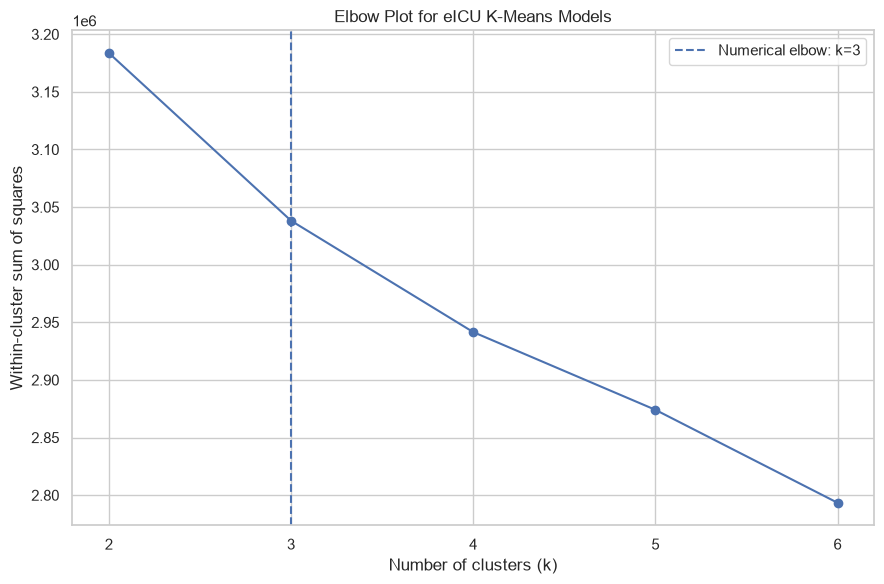

In [24]:
plt.figure(
    figsize=(
        9,
        6,
    )
)


plt.plot(
    model_comparison["k"],
    model_comparison["inertia_wcss"],
    marker="o",
)


plt.axvline(
    ELBOW_CANDIDATE_K,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Numerical elbow: "
        f"k={ELBOW_CANDIDATE_K}"
    ),
)


plt.title(
    "Elbow Plot for eICU K-Means Models"
)

plt.xlabel(
    "Number of clusters (k)"
)

plt.ylabel(
    "Within-cluster sum of squares"
)

plt.xticks(
    K_VALUES
)

plt.legend()

plt.tight_layout()


plt.savefig(
    MODEL_METRICS_PLOT_DIR
    / "elbow_plot.png",
    dpi=300,
    bbox_inches="tight",
)


plt.show()

#### Explanation :
The elbow plot shows how WCSS decreases as more clusters are added.

The preferred region is where adding another cluster produces a noticeably smaller improvement.

### Create the Average Silhouette-Score Plot

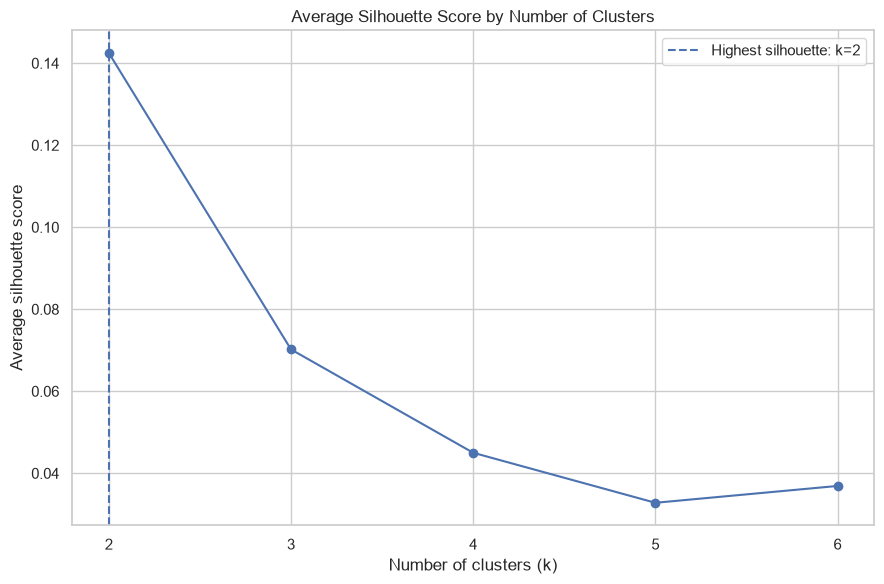

In [25]:
plt.figure(
    figsize=(
        9,
        6,
    )
)


plt.plot(
    model_comparison["k"],
    model_comparison[
        "average_silhouette"
    ],
    marker="o",
)


best_silhouette_k = int(
    model_comparison.loc[
        model_comparison[
            "average_silhouette"
        ].idxmax(),
        "k",
    ]
)


plt.axvline(
    best_silhouette_k,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Highest silhouette: "
        f"k={best_silhouette_k}"
    ),
)


plt.title(
    "Average Silhouette Score by Number of Clusters"
)

plt.xlabel(
    "Number of clusters (k)"
)

plt.ylabel(
    "Average silhouette score"
)

plt.xticks(
    K_VALUES
)

plt.legend()

plt.tight_layout()


plt.savefig(
    MODEL_METRICS_PLOT_DIR
    / "silhouette_score_plot.png",
    dpi=300,
    bbox_inches="tight",
)


plt.show()

#### Explanation :
A higher silhouette score generally indicates stronger separation and cohesion. 

It should be considered together with cluster sizes, stability and interpretability.

### Plot the Calinski-Harabasz Score

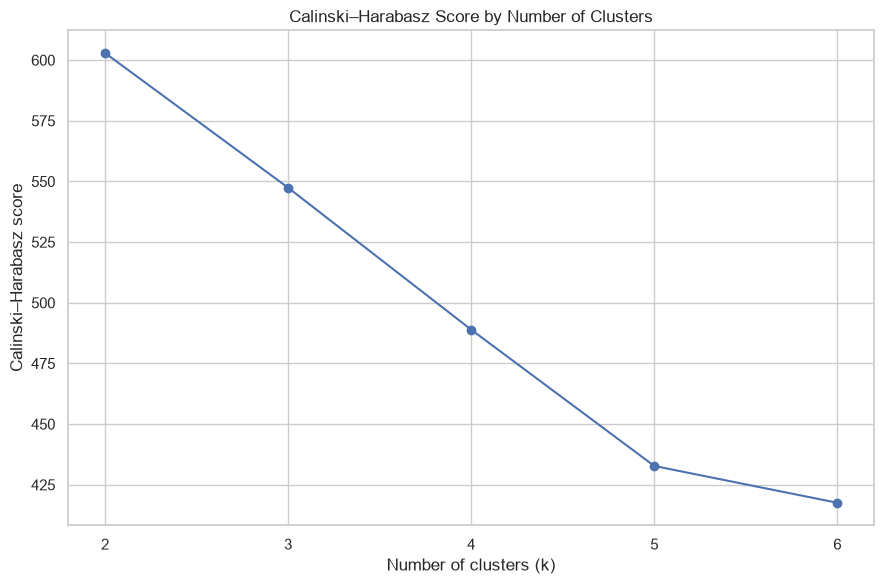

In [26]:
plt.figure(
    figsize=(
        9,
        6,
    )
)


plt.plot(
    model_comparison["k"],
    model_comparison[
        "calinski_harabasz_score"
    ],
    marker="o",
)


plt.title(
    "Calinski–Harabasz Score by Number of Clusters"
)

plt.xlabel(
    "Number of clusters (k)"
)

plt.ylabel(
    "Calinski–Harabasz score"
)

plt.xticks(
    K_VALUES
)

plt.tight_layout()


plt.savefig(
    MODEL_METRICS_PLOT_DIR
    / "calinski_harabasz_plot.png",
    dpi=300,
    bbox_inches="tight",
)


plt.show()

#### Explanation :
Higher Calinski-Harabasz scores generally indicate more compact and better-seaprated clusters. This is a supporting metric.

### Plot the Davies-Bouldin Score

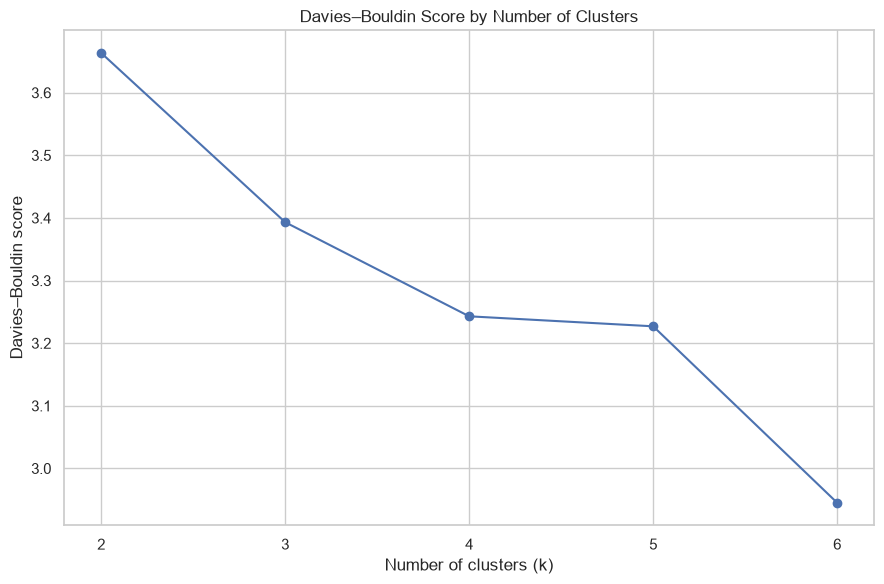

In [27]:
plt.figure(
    figsize=(
        9,
        6,
    )
)


plt.plot(
    model_comparison["k"],
    model_comparison[
        "davies_bouldin_score"
    ],
    marker="o",
)


plt.title(
    "Davies–Bouldin Score by Number of Clusters"
)

plt.xlabel(
    "Number of clusters (k)"
)

plt.ylabel(
    "Davies–Bouldin score"
)

plt.xticks(
    K_VALUES
)

plt.tight_layout()


plt.savefig(
    MODEL_METRICS_PLOT_DIR
    / "davies_bouldin_plot.png",
    dpi=300,
    bbox_inches="tight",
)


plt.show()

#### Explanation :
A lower Davies-Bouldin score is generally prefeerred. It is used as supporting evidence rather than as the only selection rule.

### Create Detailed Silhouette Plots

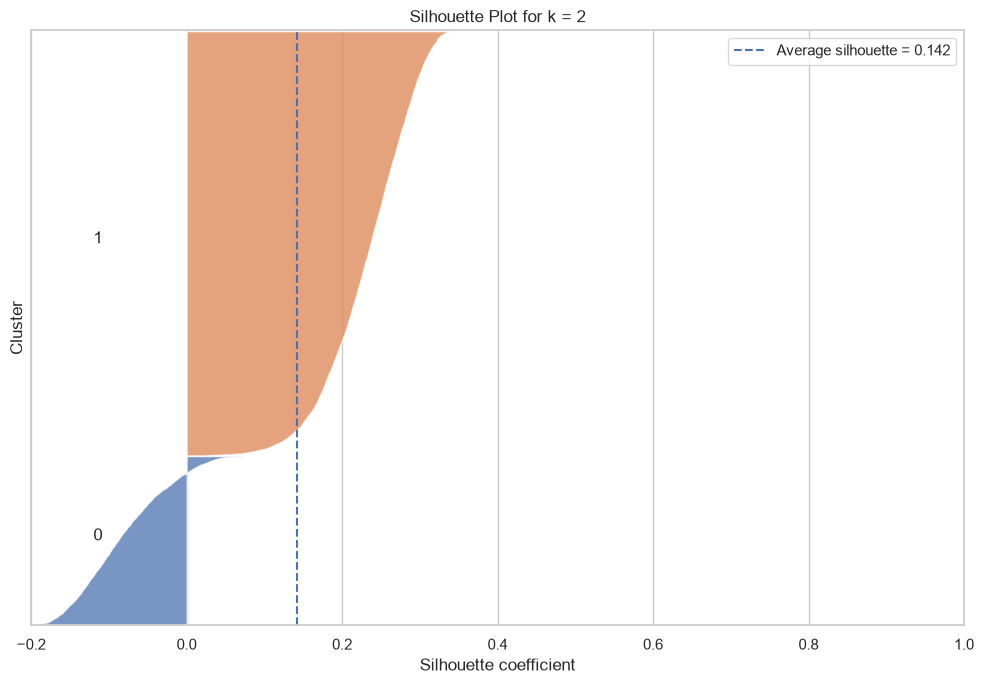

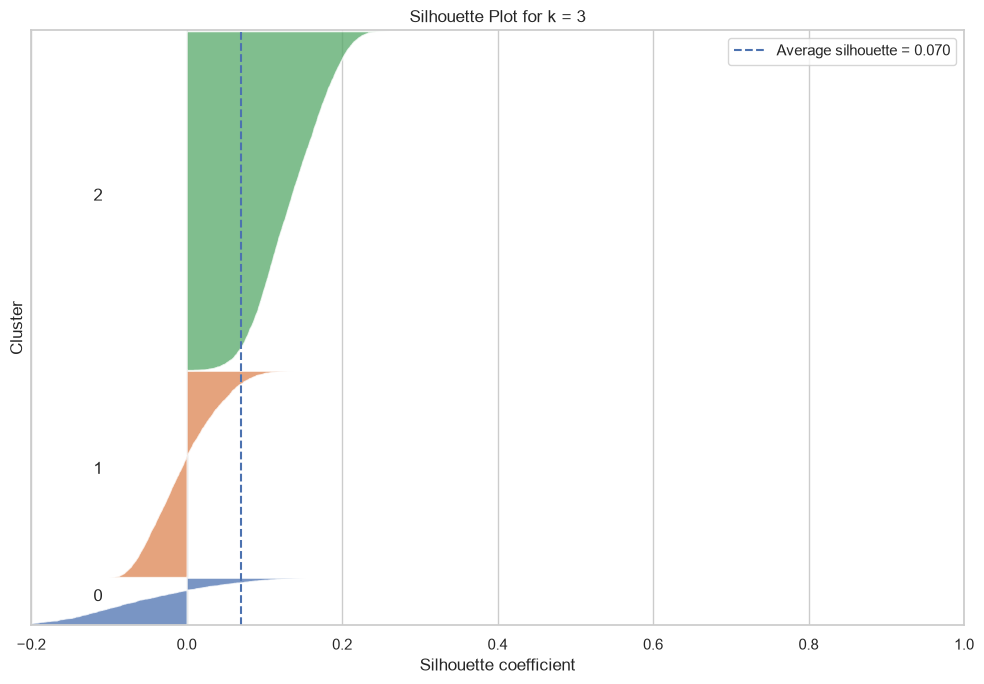

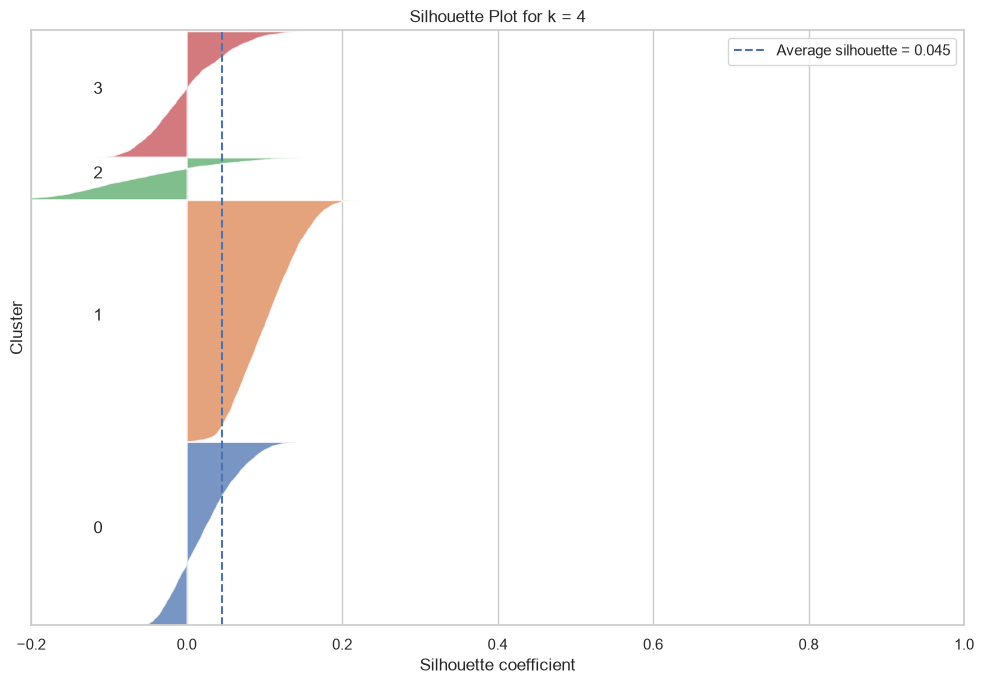

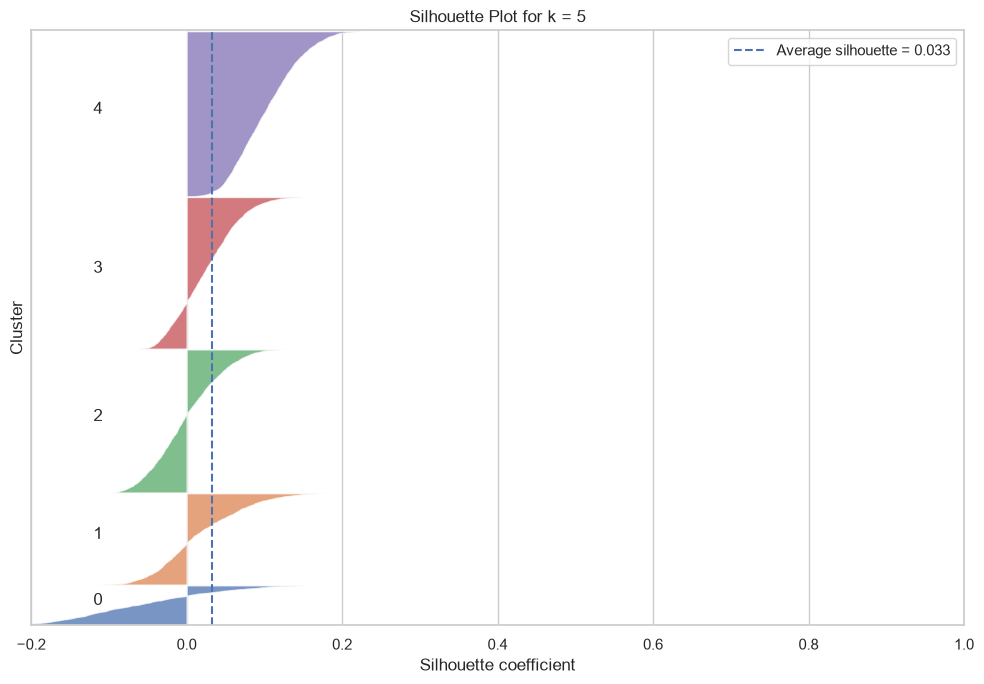

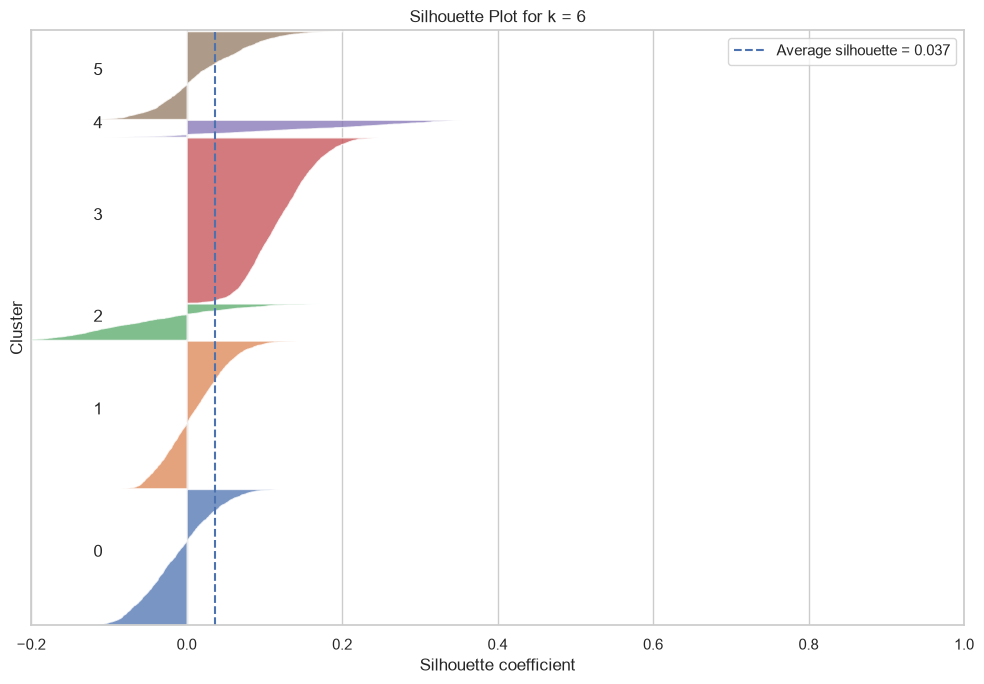

In [28]:
for k in K_VALUES:

    sampled_labels = (
        silhouette_details[k][
            "labels"
        ]
    )

    silhouette_values = (
        silhouette_details[k][
            "values"
        ]
    )

    average_silhouette = (
        silhouette_details[k][
            "average"
        ]
    )


    figure, axis = plt.subplots(
        figsize=(
            10,
            7,
        )
    )


    axis.set_xlim(
        [
            -0.20,
            1.00,
        ]
    )


    axis.set_ylim(
        [
            0,
            len(X_silhouette)
            + (
                k + 1
            )
            * 10,
        ]
    )


    y_lower = 10


    for cluster_number in range(k):

        cluster_silhouette_values = (
            silhouette_values[
                sampled_labels
                == cluster_number
            ]
        )


        cluster_silhouette_values.sort()


        cluster_size = len(
            cluster_silhouette_values
        )


        y_upper = (
            y_lower
            + cluster_size
        )


        axis.fill_betweenx(
            np.arange(
                y_lower,
                y_upper,
            ),
            0,
            cluster_silhouette_values,
            alpha=0.75,
        )


        axis.text(
            -0.12,
            y_lower
            + 0.5
            * cluster_size,
            str(
                cluster_number
            ),
        )


        y_lower = (
            y_upper
            + 10
        )


    axis.axvline(
        average_silhouette,
        linestyle="--",
        linewidth=1.5,
        label=(
            "Average silhouette = "
            f"{average_silhouette:.3f}"
        ),
    )


    axis.set_title(
        f"Silhouette Plot for k = {k}"
    )

    axis.set_xlabel(
        "Silhouette coefficient"
    )

    axis.set_ylabel(
        "Cluster"
    )

    axis.set_yticks([])

    axis.legend()

    figure.tight_layout()


    figure.savefig(
        SILHOUETTE_PLOT_DIR
        / f"silhouette_k{k}.png",
        dpi=300,
        bbox_inches="tight",
    )


    plt.show()

#### Explanation :
Each silhouette plot shows the distribution of individual silhouette coefficients.

Review whether :
- Most values are positive.
- Clusters have reasonable widths.
- A large number of observations have values near or below zero.
- One cluster has much weaker separation than the others.

### Create Cluster-Size Plots

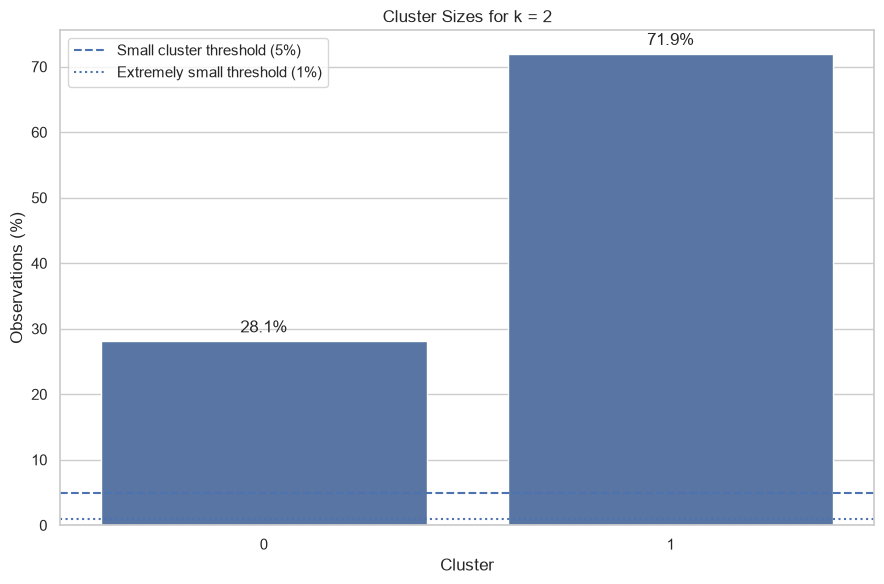

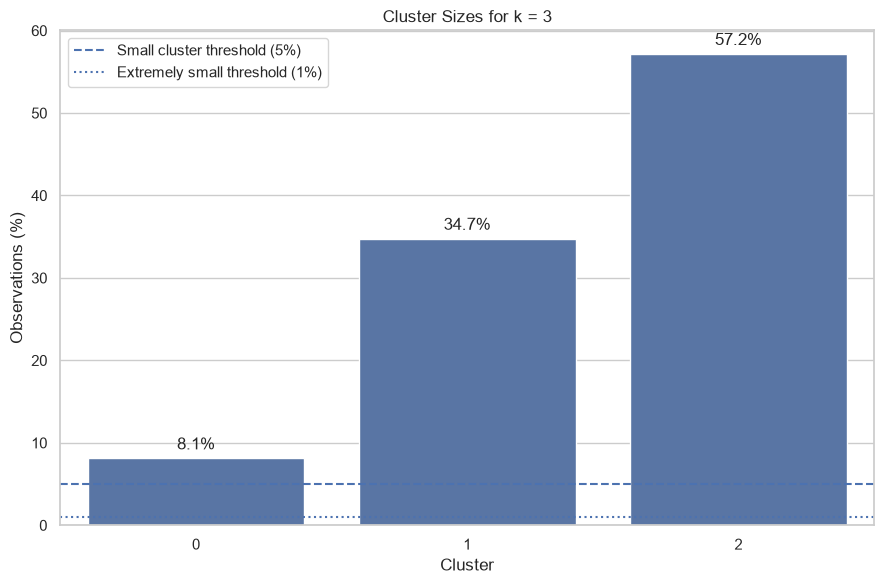

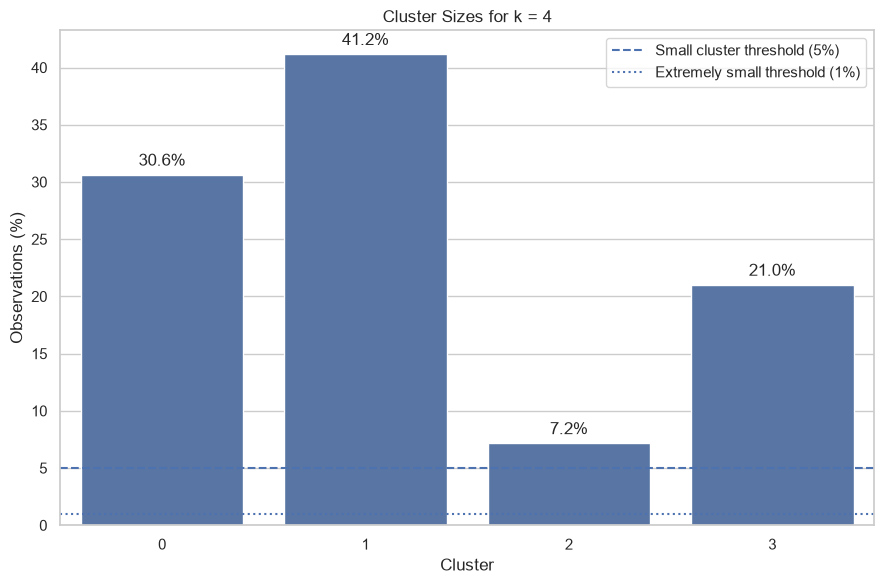

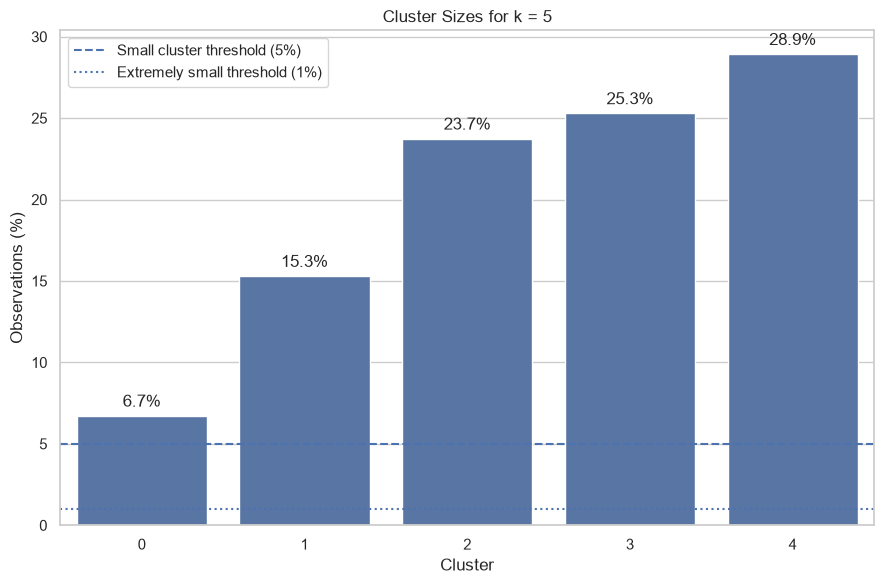

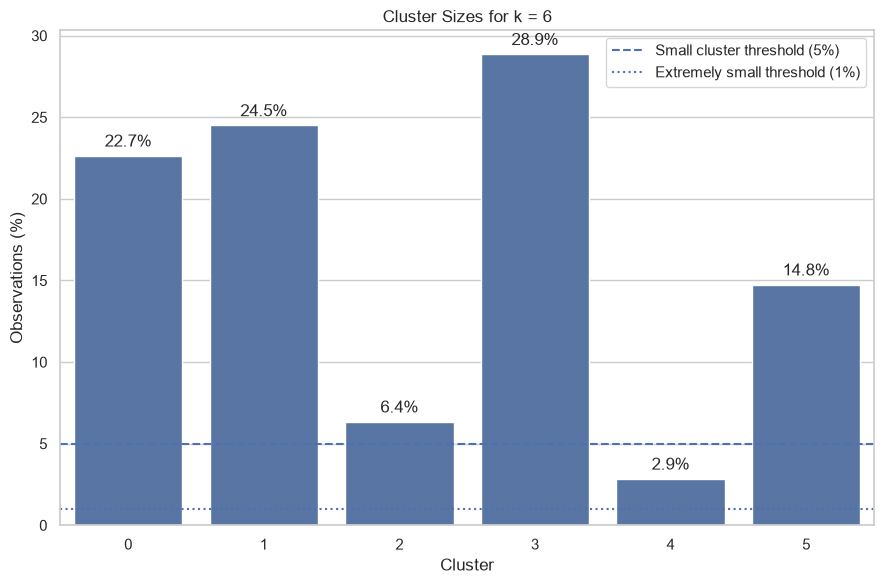

In [29]:
for k in K_VALUES:

    current_sizes = (
        cluster_size_summary[
            cluster_size_summary[
                "k"
            ]
            == k
        ]
        .copy()
    )


    plt.figure(
        figsize=(
            9,
            6,
        )
    )


    size_axis = sns.barplot(
        data=current_sizes,
        x="cluster",
        y="observation_percent",
    )


    for bar, percentage in zip(
        size_axis.patches,
        current_sizes[
            "observation_percent"
        ],
    ):

        size_axis.annotate(
            f"{percentage:.1f}%",
            (
                bar.get_x()
                + bar.get_width()
                / 2,
                bar.get_height(),
            ),
            ha="center",
            va="bottom",
            xytext=(
                0,
                4,
            ),
            textcoords="offset points",
        )


    plt.axhline(
        SMALL_CLUSTER_PERCENT,
        linestyle="--",
        linewidth=1.5,
        label=(
            f"Small cluster threshold "
            f"({SMALL_CLUSTER_PERCENT:.0f}%)"
        ),
    )


    plt.axhline(
        EXTREMELY_SMALL_CLUSTER_PERCENT,
        linestyle=":",
        linewidth=1.5,
        label=(
            "Extremely small threshold "
            f"({EXTREMELY_SMALL_CLUSTER_PERCENT:.0f}%)"
        ),
    )


    plt.title(
        f"Cluster Sizes for k = {k}"
    )

    plt.xlabel(
        "Cluster"
    )

    plt.ylabel(
        "Observations (%)"
    )

    plt.legend()

    plt.tight_layout()


    plt.savefig(
        CLUSTER_SIZE_PLOT_DIR
        / f"cluster_sizes_k{k}.png",
        dpi=300,
        bbox_inches="tight",
    )


    plt.show()

#### Explanation :
These plots show whether candidate solutions produce balanced clusters or very small groups.

A small cluster is not automatically invalid. It may represent a rare clinical subgroup but it requires careful review.

### Test Stability Across Alternative Random Seeds

In [30]:
seed_run_rows = []
pairwise_stability_rows = []
stability_summary_rows = []


print("=" * 90)
print("TESTING STABILITY ACROSS RANDOM SEEDS")
print("=" * 90)


for k in K_VALUES:

    print(
        f"\nTesting stability for k = {k}"
    )


    labels_by_seed = {}


    for seed in STABILITY_RANDOM_SEEDS:

        seed_model = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=N_INIT,
            max_iter=MAX_ITERATIONS,
            tol=TOLERANCE,
            random_state=seed,
            algorithm="lloyd",
        )


        seed_labels = (
            seed_model.fit_predict(
                X
            )
        )


        labels_by_seed[
            seed
        ] = seed_labels


        seed_cluster_sizes = (
            summarize_cluster_sizes(
                seed_labels,
                k,
            )
        )


        seed_run_rows.append(
            {
                "k": k,
                "random_seed": seed,
                "inertia_wcss": float(
                    seed_model.inertia_
                ),
                "number_of_iterations": int(
                    seed_model.n_iter_
                ),
                "smallest_cluster_count": int(
                    seed_cluster_sizes[
                        "observation_count"
                    ].min()
                ),
                "smallest_cluster_percent": float(
                    seed_cluster_sizes[
                        "observation_percent"
                    ].min()
                ),
                "any_small_cluster": bool(
                    seed_cluster_sizes[
                        "small_cluster"
                    ].any()
                ),
                "any_extremely_small_cluster": bool(
                    seed_cluster_sizes[
                        "extremely_small_cluster"
                    ].any()
                ),
            }
        )


    pairwise_ari_values = []


    for seed_1, seed_2 in combinations(
        STABILITY_RANDOM_SEEDS,
        2,
    ):

        pairwise_ari = adjusted_rand_score(
            labels_by_seed[
                seed_1
            ],
            labels_by_seed[
                seed_2
            ],
        )


        pairwise_ari_values.append(
            pairwise_ari
        )


        pairwise_stability_rows.append(
            {
                "k": k,
                "seed_1": seed_1,
                "seed_2": seed_2,
                "adjusted_rand_index": float(
                    pairwise_ari
                ),
            }
        )


    mean_pairwise_ari = float(
        np.mean(
            pairwise_ari_values
        )
    )


    minimum_pairwise_ari = float(
        np.min(
            pairwise_ari_values
        )
    )


    maximum_pairwise_ari = float(
        np.max(
            pairwise_ari_values
        )
    )


    stability_summary_rows.append(
        {
            "k": k,
            "mean_pairwise_ari": (
                mean_pairwise_ari
            ),
            "minimum_pairwise_ari": (
                minimum_pairwise_ari
            ),
            "maximum_pairwise_ari": (
                maximum_pairwise_ari
            ),
            "stable_mean_ari_at_least_0_90": (
                mean_pairwise_ari
                >= 0.90
            ),
            "stable_minimum_ari_at_least_0_80": (
                minimum_pairwise_ari
                >= 0.80
            ),
        }
    )


    print(
        f"Mean pairwise ARI: "
        f"{mean_pairwise_ari:.4f}"
    )

    print(
        f"Minimum pairwise ARI: "
        f"{minimum_pairwise_ari:.4f}"
    )

TESTING STABILITY ACROSS RANDOM SEEDS

Testing stability for k = 2
Mean pairwise ARI: 0.9908
Minimum pairwise ARI: 0.9818

Testing stability for k = 3
Mean pairwise ARI: 0.9851
Minimum pairwise ARI: 0.9690

Testing stability for k = 4
Mean pairwise ARI: 0.9796
Minimum pairwise ARI: 0.9698

Testing stability for k = 5
Mean pairwise ARI: 0.7480
Minimum pairwise ARI: 0.4361

Testing stability for k = 6
Mean pairwise ARI: 0.6247
Minimum pairwise ARI: 0.4259


#### Explanation :
Each candidate value of `k` is refitted using five random seeds.

The Adjusted Rand Index compares the patient assignments across runs. It is not affected by arbitrary cluster-number labels.

Higher ARI values indicate greater stability.


### Save the Stability Results

In [31]:
seed_stability_runs = pd.DataFrame(
    seed_run_rows
)


seed_stability_pairwise = pd.DataFrame(
    pairwise_stability_rows
)


seed_stability_summary = pd.DataFrame(
    stability_summary_rows
).sort_values(
    "k"
).reset_index(
    drop=True
)


seed_stability_runs.to_csv(
    RESULTS_DIR
    / "seed_stability_runs.csv",
    index=False,
)


seed_stability_pairwise.to_csv(
    RESULTS_DIR
    / "seed_stability_pairwise.csv",
    index=False,
)


seed_stability_summary.to_csv(
    RESULTS_DIR
    / "seed_stability_summary.csv",
    index=False,
)


seed_stability_summary

,k,mean_pairwise_ari,minimum_pairwise_ari,maximum_pairwise_ari,stable_mean_ari_at_least_0_90,stable_minimum_ari_at_least_0_80
0,2,0.990844,0.981775,0.997399,True,True
1,3,0.985107,0.969001,0.993485,True,True
2,4,0.979572,0.969777,0.995743,True,True
3,5,0.748032,0.436088,0.996115,False,False
4,6,0.624724,0.425920,0.998790,False,False


#### Explanation :
Three stability tables are saved :
- Results from every seed.
- Pairwuse ARI comparisons
- Overall stability summary for each candidate value of `k`.

### Add Stability to the Main Comparison Table

In [32]:
model_comparison = model_comparison.merge(
    seed_stability_summary,
    on="k",
    how="left",
    validate="one_to_one",
)


model_comparison.to_csv(
    RESULTS_DIR
    / "kmeans_model_comparison.csv",
    index=False,
)


model_comparison

,k,inertia_wcss,average_silhouette,calinski_harabasz_score,davies_bouldin_score,number_of_iterations,smallest_cluster_count,smallest_cluster_percent,any_small_cluster,any_extremely_small_cluster,minimum_center_distance,mean_center_distance,maximum_center_distance,mean_top_feature_strength,minimum_cluster_profile_strength,wcss_reduction_from_previous_percent,elbow_distance,mean_pairwise_ari,minimum_pairwise_ari,maximum_pairwise_ari,stable_mean_ari_at_least_0_90,stable_minimum_ari_at_least_0_80
0,2,3.183756e+06,0.142482,602.940393,3.663451,13,32719,28.067391,False,False,2.891309,2.891309,2.891309,0.489462,0.275010,NaN,0.000000,0.990844,0.981775,0.997399,True,True
1,3,3.038199e+06,0.070190,547.414761,3.393162,26,9449,8.105651,False,False,2.459890,4.005094,4.960454,0.877022,0.383913,4.571851,0.086876,0.985107,0.969001,0.993485,True,True
2,4,2.941524e+06,0.044988,488.920412,3.242891,15,8360,7.171472,False,False,2.363150,3.920631,5.321565,0.868634,0.437583,3.181979,0.085210,0.979572,0.969777,0.995743,True,True
3,5,2.874059e+06,0.032794,432.748184,3.226931,93,7842,6.727115,False,False,2.288202,3.851198,5.521636,0.884841,0.533903,2.293549,0.030636,0.748032,0.436088,0.996115,False,False
4,6,2.793378e+06,0.036898,417.578219,2.945116,30,3329,2.855721,True,False,2.275193,4.565807,6.758256,0.978108,0.536190,2.807208,0.000000,0.624724,0.425920,0.998790,False,False


#### Explanation :
The final comparison table now includes :
- WCSS
- WCSS improvement
- Silhouette score
- Supporting metrics
- Cluster sizes
- Small-cluster warnings
- Center separation
- Stability across seeds

### Create the Stability Plot

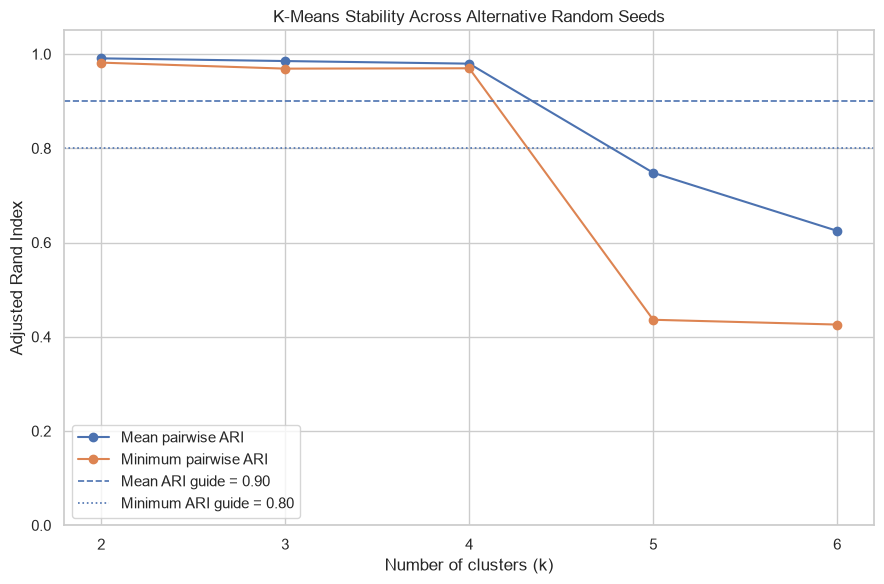

In [33]:
plt.figure(
    figsize=(
        9,
        6,
    )
)


plt.plot(
    seed_stability_summary["k"],
    seed_stability_summary[
        "mean_pairwise_ari"
    ],
    marker="o",
    label="Mean pairwise ARI",
)


plt.plot(
    seed_stability_summary["k"],
    seed_stability_summary[
        "minimum_pairwise_ari"
    ],
    marker="o",
    label="Minimum pairwise ARI",
)


plt.axhline(
    0.90,
    linestyle="--",
    linewidth=1.2,
    label="Mean ARI guide = 0.90",
)


plt.axhline(
    0.80,
    linestyle=":",
    linewidth=1.2,
    label="Minimum ARI guide = 0.80",
)


plt.title(
    "K-Means Stability Across Alternative Random Seeds"
)

plt.xlabel(
    "Number of clusters (k)"
)

plt.ylabel(
    "Adjusted Rand Index"
)

plt.xticks(
    K_VALUES
)

plt.ylim(
    0,
    1.05,
)

plt.legend()

plt.tight_layout()


plt.savefig(
    STABILITY_PLOT_DIR
    / "seed_stability.png",
    dpi=300,
    bbox_inches="tight",
)


plt.show()

#### Explanation :
This plot compares the mean and minimum stability across seeds.

A stable solution should produce similar cluster assignments even when the initialization seed changes.

### Perform PCA for Visualization

In [34]:
pca_model = PCA(
    n_components=2,
    svd_solver="randomized",
    random_state=PRIMARY_RANDOM_SEED,
)


pca_coordinates = pca_model.fit_transform(
    X
)


pca_explained_variance = pd.DataFrame(
    {
        "principal_component": [
            "PC1",
            "PC2",
        ],
        "explained_variance_ratio": (
            pca_model.explained_variance_ratio_
        ),
        "explained_variance_percent": (
            pca_model.explained_variance_ratio_
            * 100
        ),
    }
)


pca_explained_variance.to_csv(
    RESULTS_DIR
    / "pca_explained_variance.csv",
    index=False,
)


print(
    "Variance explained by PC1 and PC2:"
)

display(
    pca_explained_variance
)

Variance explained by PC1 and PC2:


,principal_component,explained_variance_ratio,explained_variance_percent
0,PC1,0.096774,9.677424
1,PC2,0.070627,7.062727


#### Explanation :
PCA reduces the $29$-dimensional matrix to two dimensions for visualization.

KMeans is still fitted using all $29$ variables. PCA is not used to create the clusters.

### Create PCA Cluster Plots

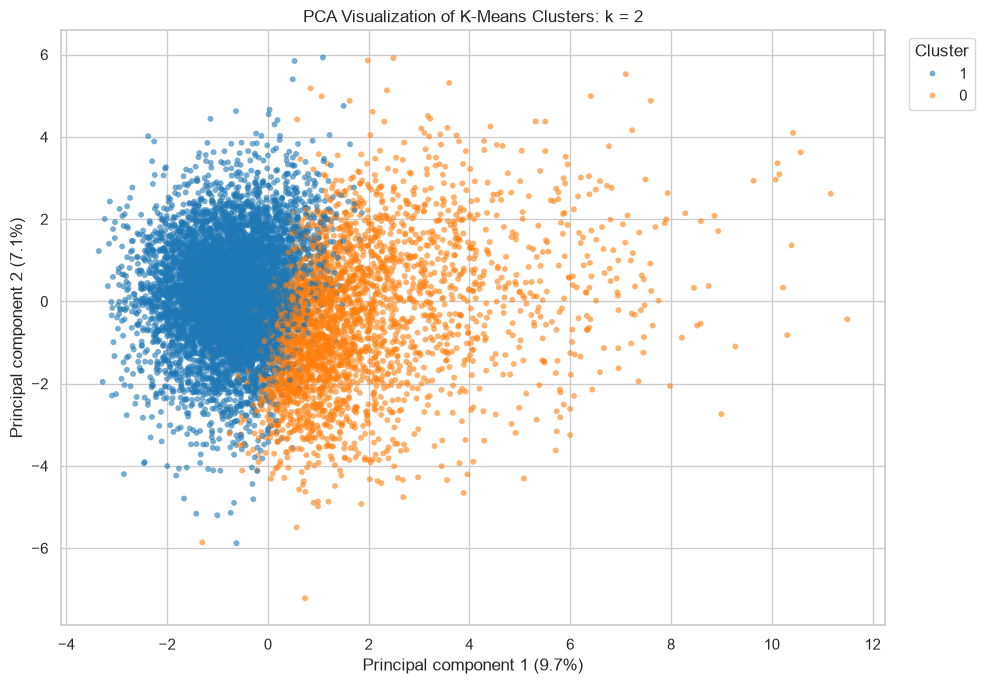

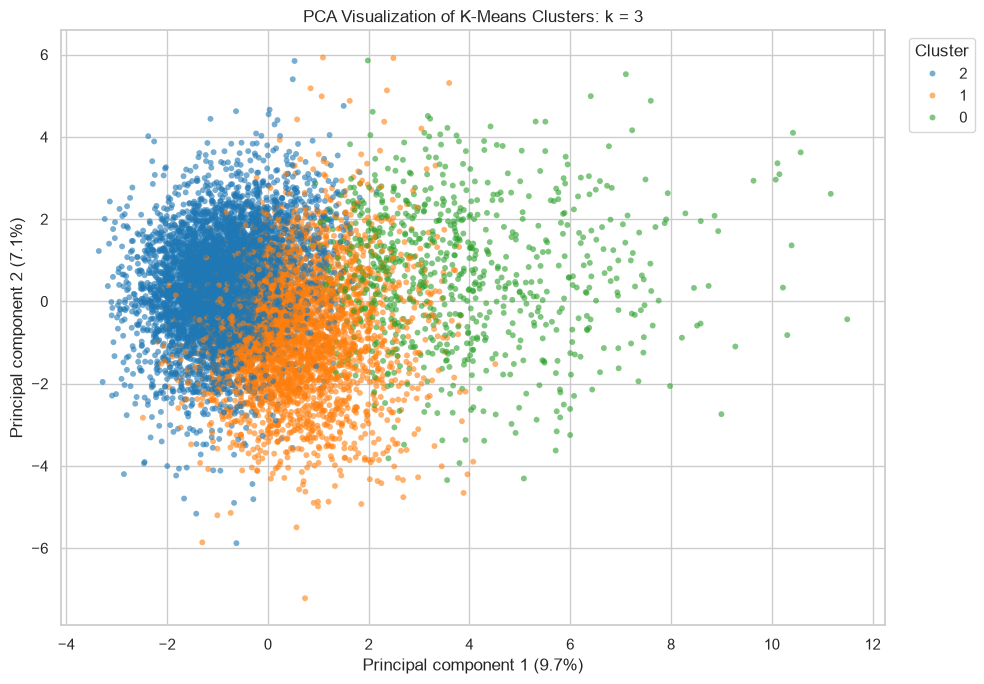

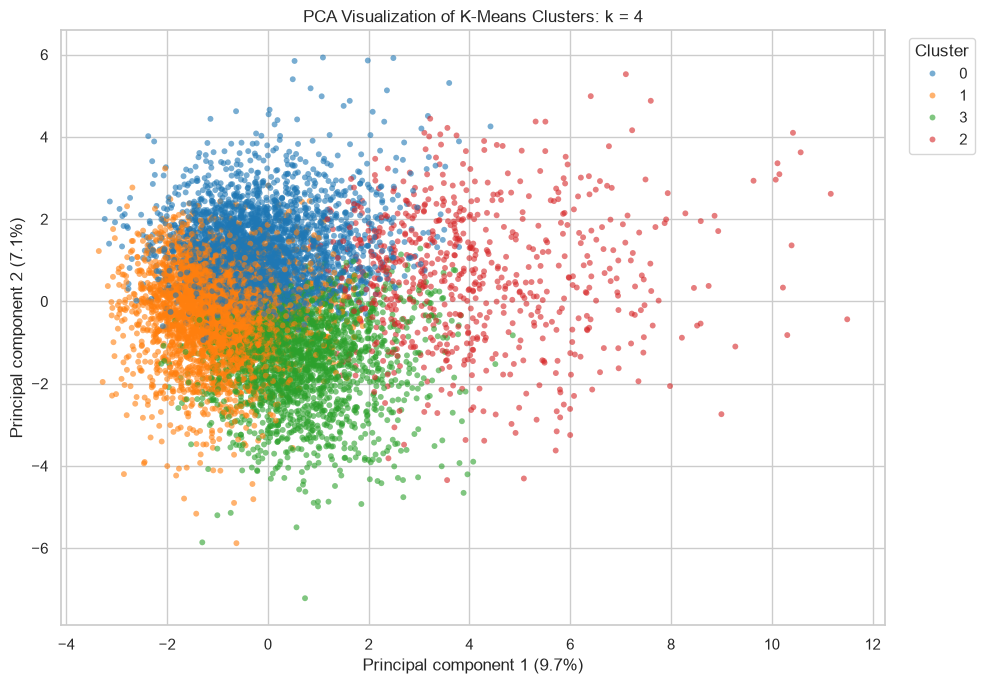

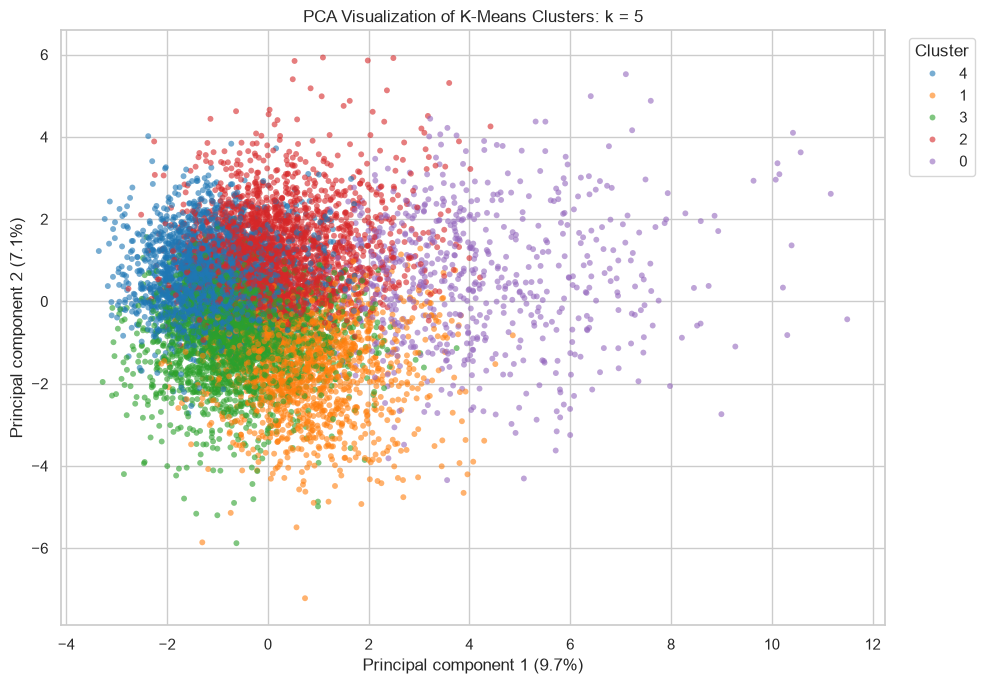

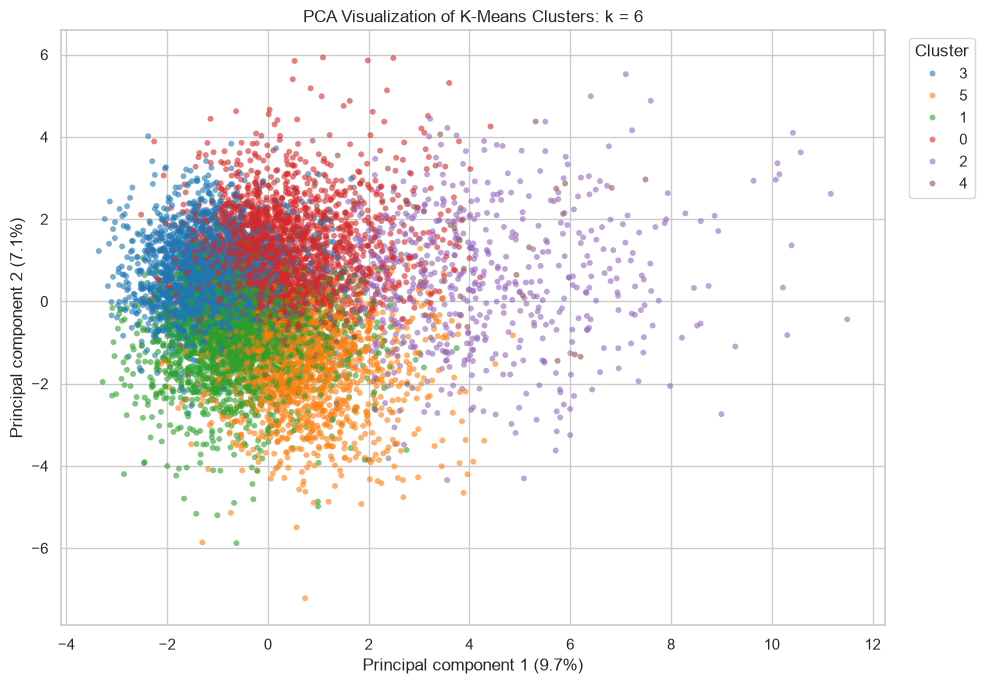

In [35]:
pca_sample_coordinates = pd.DataFrame(
    {
        ID_COLUMN: (
            row_ids.iloc[
                pca_plot_indices
            ][
                ID_COLUMN
            ]
            .reset_index(
                drop=True
            )
        ),

        "original_row_index": (
            pca_plot_indices
        ),

        "principal_component_1": (
            pca_coordinates[
                pca_plot_indices,
                0,
            ]
        ),

        "principal_component_2": (
            pca_coordinates[
                pca_plot_indices,
                1,
            ]
        ),
    }
)


for k in K_VALUES:

    current_pca_data = (
        pca_sample_coordinates.copy()
    )


    current_pca_data[
        "cluster"
    ] = (
        primary_labels[k][
            pca_plot_indices
        ]
        .astype(str)
    )


    current_pca_data.to_csv(
        RESULTS_DIR
        / f"pca_plot_coordinates_k{k}.csv",
        index=False,
    )


    plt.figure(
        figsize=(
            10,
            7,
        )
    )


    sns.scatterplot(
        data=current_pca_data,
        x="principal_component_1",
        y="principal_component_2",
        hue="cluster",
        palette="tab10",
        s=18,
        alpha=0.60,
        linewidth=0,
    )


    plt.title(
        f"PCA Visualization of K-Means Clusters: k = {k}"
    )

    plt.xlabel(
        (
            "Principal component 1 "
            f"({pca_model.explained_variance_ratio_[0] * 100:.1f}%)"
        )
    )

    plt.ylabel(
        (
            "Principal component 2 "
            f"({pca_model.explained_variance_ratio_[1] * 100:.1f}%)"
        )
    )

    plt.legend(
        title="Cluster",
        bbox_to_anchor=(
            1.02,
            1,
        ),
        loc="upper left",
    )

    plt.tight_layout()


    plt.savefig(
        PCA_PLOT_DIR
        / f"pca_clusters_k{k}.png",
        dpi=300,
        bbox_inches="tight",
    )


    plt.show()

#### Explanation :
These plots show the candidate cluster assignments in two-dimensional PCA space.

Overlap in these plots does not automatically mean that the clustering is poor because the actual clustering uses 29 dimensions.

### Create Standardized Cluster-Center Heatmaps

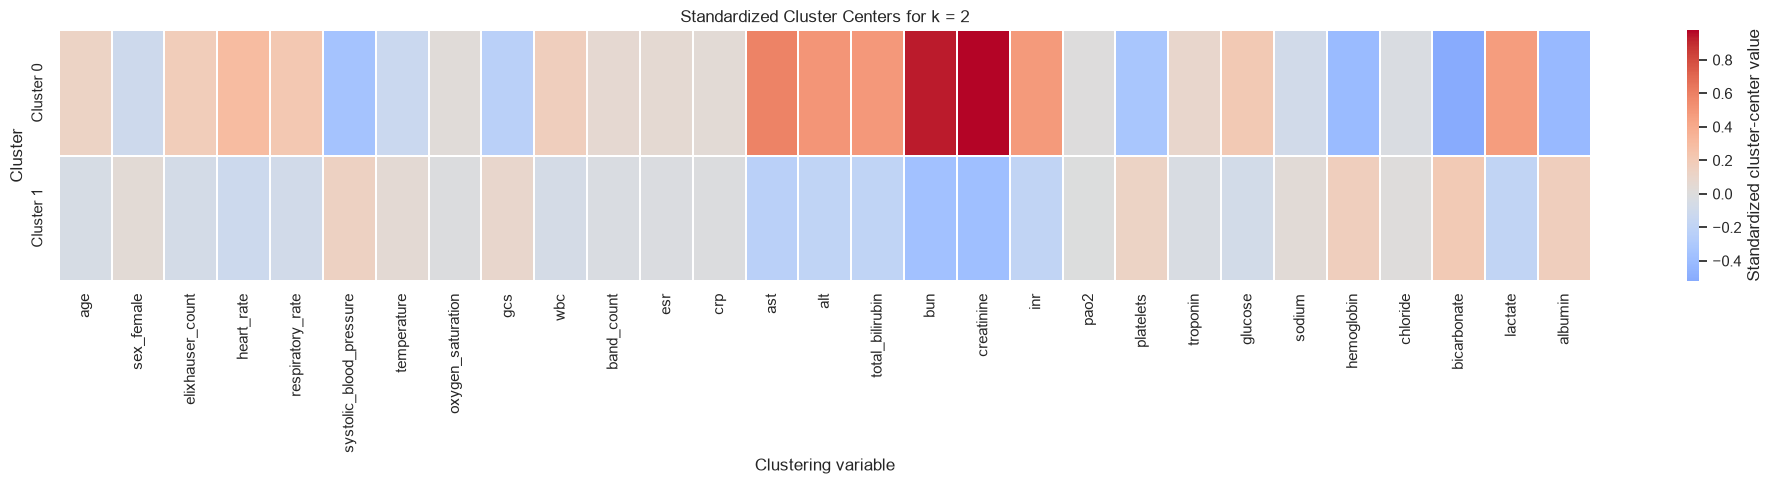

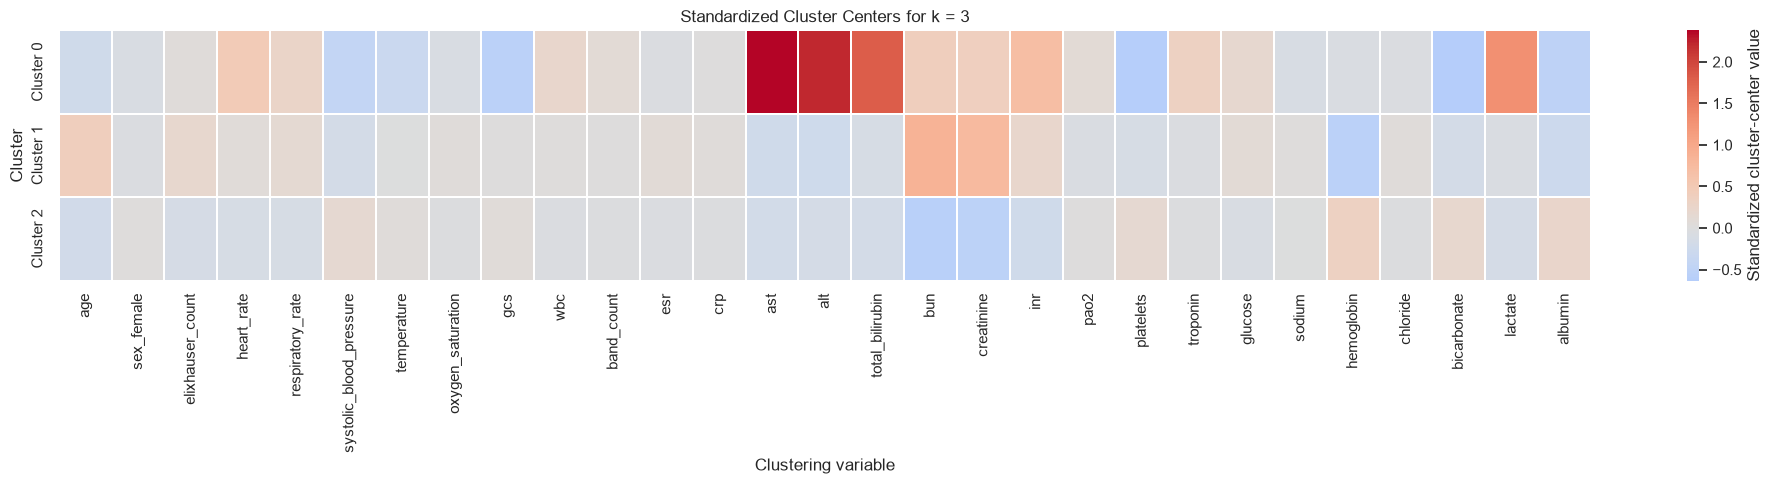

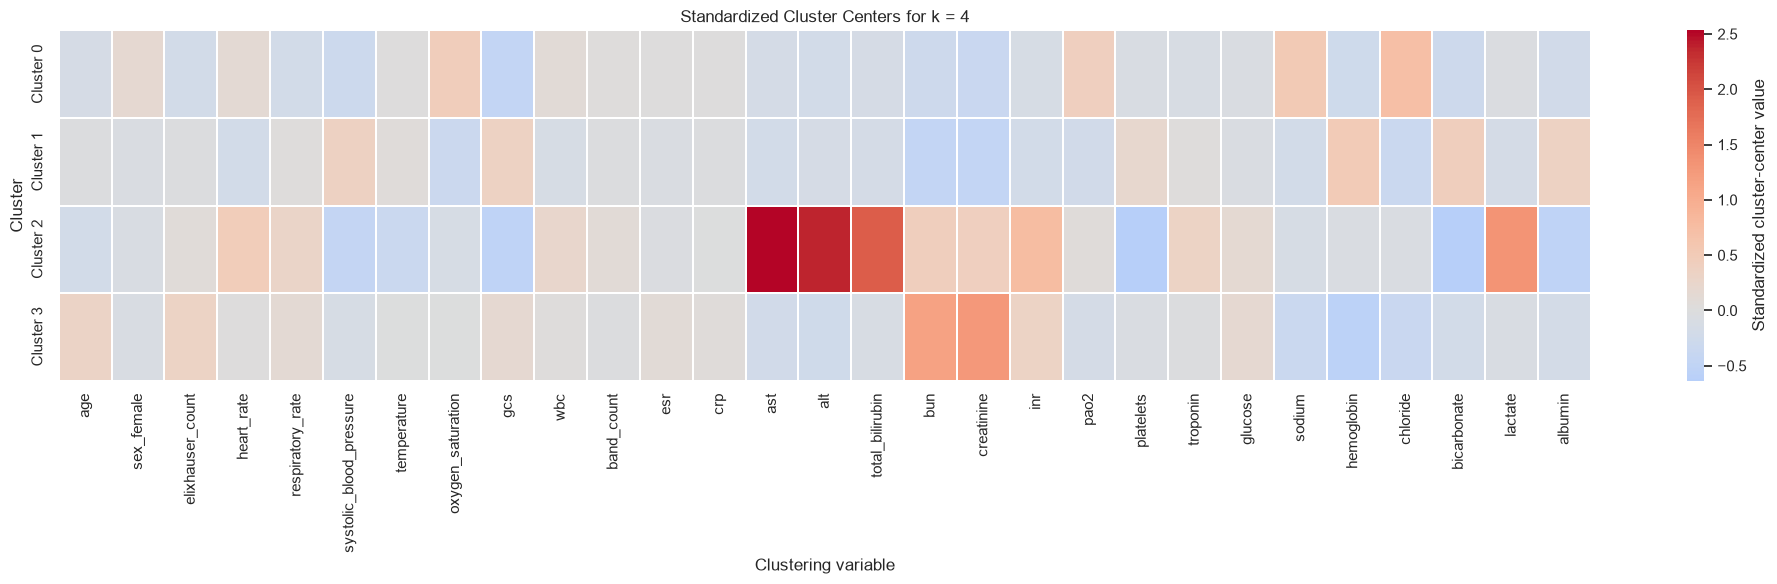

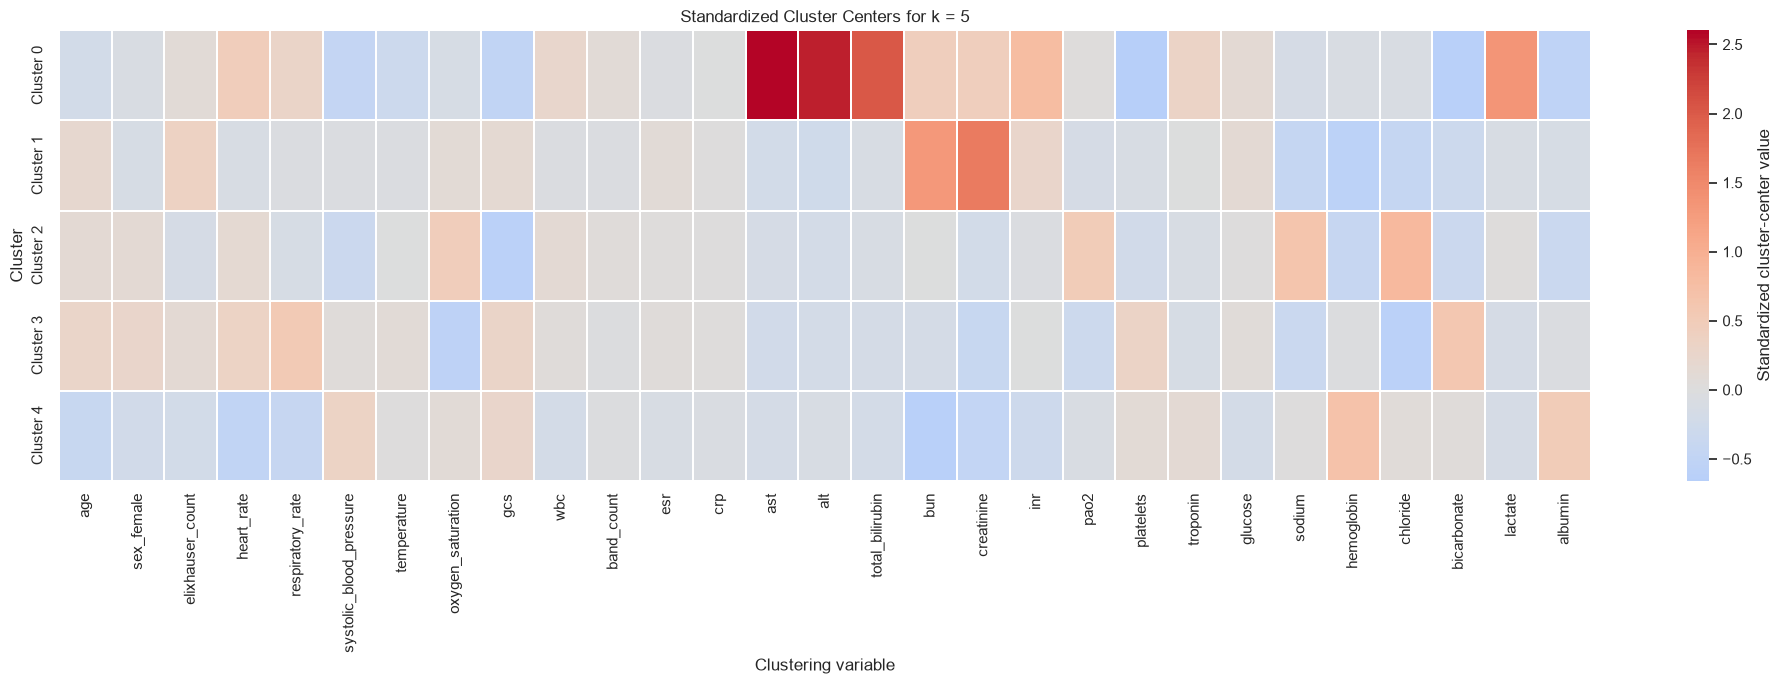

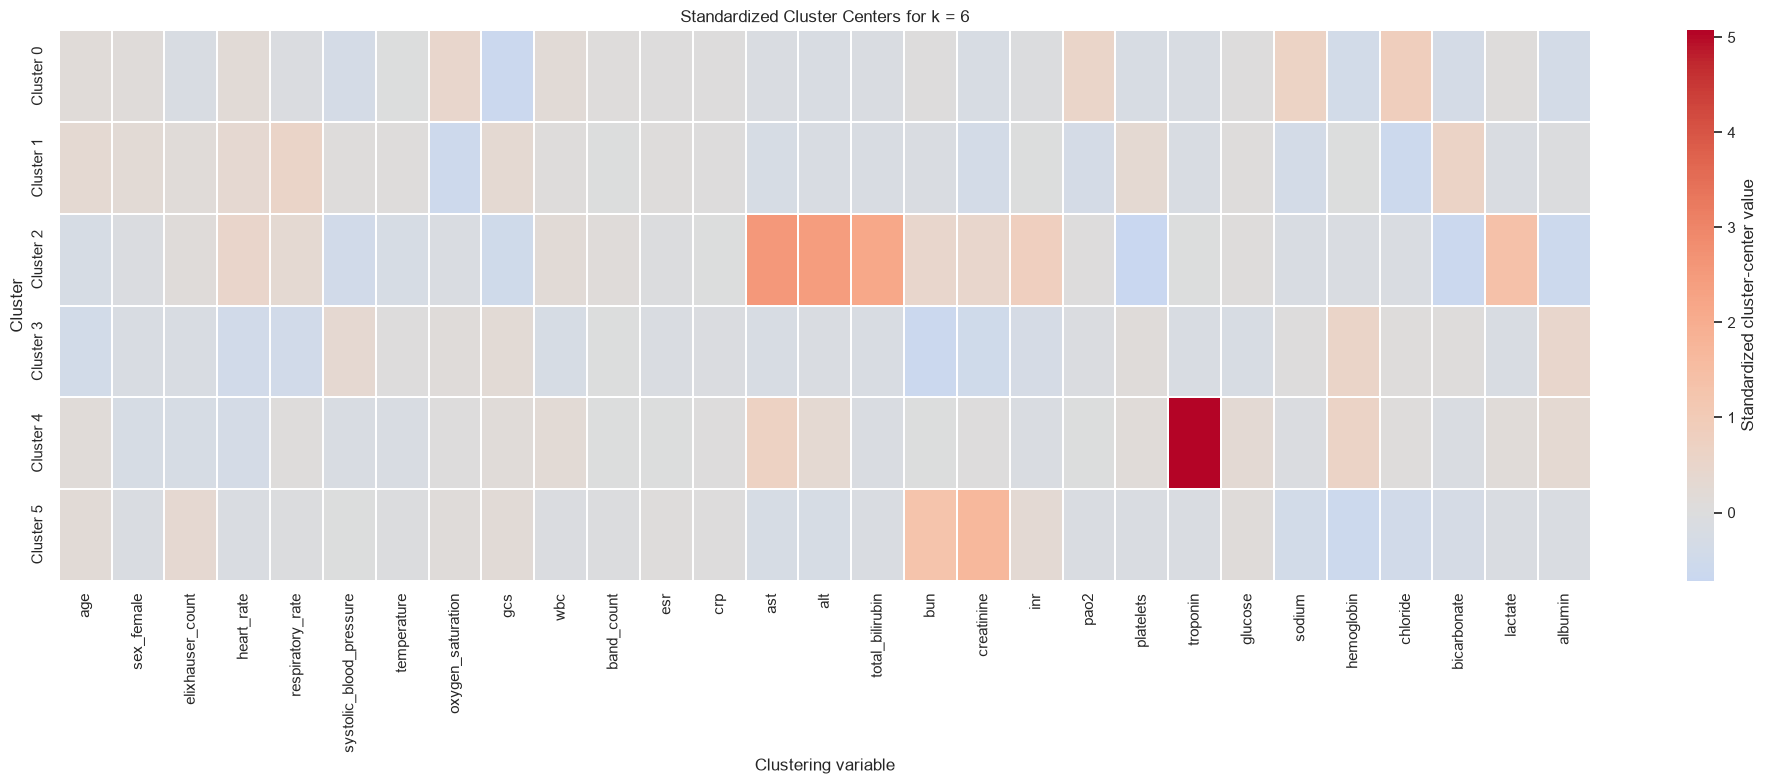

In [36]:
for k in K_VALUES:

    center_table = pd.DataFrame(
        primary_models[k].cluster_centers_,
        columns=FEATURES,
        index=[
            f"Cluster {cluster_number}"
            for cluster_number in range(k)
        ],
    )


    plt.figure(
        figsize=(
            20,
            max(
                5,
                k + 2,
            ),
        )
    )


    sns.heatmap(
        center_table,
        cmap="coolwarm",
        center=0,
        linewidths=0.25,
        cbar_kws={
            "label": (
                "Standardized cluster-center value"
            )
        },
    )


    plt.title(
        f"Standardized Cluster Centers for k = {k}"
    )

    plt.xlabel(
        "Clustering variable"
    )

    plt.ylabel(
        "Cluster"
    )

    plt.tight_layout()


    plt.savefig(
        CENTER_PLOT_DIR
        / f"standardized_centers_k{k}.png",
        dpi=300,
        bbox_inches="tight",
    )


    plt.show()

#### Explanation :
The heatmaps show whether the candidate clusters have distinct clinical-variable patterns.

- Positive values are above the overall standardized average.
- Negative values are below the overall standardized average.
- Values near zero are close to the overall average.

These plots support interpretability and clinical-plausibility review.

### Display the Top Distinguishing Variables

In [37]:
for k in K_VALUES:

    print("=" * 90)
    print(
        f"TOP DISTINGUISHING VARIABLES FOR k = {k}"
    )
    print("=" * 90)

    display(
        top_features_by_k[k]
    )

TOP DISTINGUISHING VARIABLES FOR k = 2


,k,cluster,rank,variable,standardized_center_value,absolute_center_value,direction
0,2,0,1,creatinine,0.975594,0.975594,above overall average
1,2,0,2,bun,0.933623,0.933623,above overall average
2,2,0,3,ast,0.587982,0.587982,above overall average
3,2,0,4,bicarbonate,-0.518228,0.518228,below overall average
4,2,0,5,alt,0.504142,0.504142,above overall average
5,2,1,1,creatinine,-0.381153,0.381153,below overall average
6,2,1,2,bun,-0.364755,0.364755,below overall average
7,2,1,3,ast,-0.229717,0.229717,below overall average
8,2,1,4,bicarbonate,0.202465,0.202465,above overall average
9,2,1,5,alt,-0.196962,0.196962,below overall average


TOP DISTINGUISHING VARIABLES FOR k = 3


,k,cluster,rank,variable,standardized_center_value,absolute_center_value,direction
0,3,0,1,ast,2.378269,2.378269,above overall average
1,3,0,2,alt,2.203484,2.203484,above overall average
2,3,0,3,total_bilirubin,1.805767,1.805767,above overall average
3,3,0,4,lactate,1.290920,1.290920,above overall average
4,3,0,5,inr,0.694985,0.694985,above overall average
5,3,1,1,bun,0.866801,0.866801,above overall average
6,3,1,2,creatinine,0.758658,0.758658,above overall average
7,3,1,3,hemoglobin,-0.547889,0.547889,below overall average
8,3,1,4,age,0.403967,0.403967,above overall average
9,3,1,5,albumin,-0.285029,0.285029,below overall average


TOP DISTINGUISHING VARIABLES FOR k = 4


,k,cluster,rank,variable,standardized_center_value,absolute_center_value,direction
0,4,0,1,chloride,0.724543,0.724543,above overall average
1,4,0,2,sodium,0.522385,0.522385,above overall average
2,4,0,3,gcs,-0.454990,0.454990,below overall average
3,4,0,4,oxygen_saturation,0.448610,0.448610,above overall average
4,4,0,5,pao2,0.410079,0.410079,above overall average
5,4,1,1,hemoglobin,0.494164,0.494164,above overall average
6,4,1,2,bun,-0.453552,0.453552,below overall average
7,4,1,3,creatinine,-0.452042,0.452042,below overall average
8,4,1,4,bicarbonate,0.423345,0.423345,above overall average
9,4,1,5,systolic_blood_pressure,0.364811,0.364811,above overall average


TOP DISTINGUISHING VARIABLES FOR k = 5


,k,cluster,rank,variable,standardized_center_value,absolute_center_value,direction
0,5,0,1,ast,2.601138,2.601138,above overall average
1,5,0,2,alt,2.454492,2.454492,above overall average
2,5,0,3,total_bilirubin,2.012050,2.012050,above overall average
3,5,0,4,lactate,1.349389,1.349389,above overall average
4,5,0,5,inr,0.788753,0.788753,above overall average
5,5,1,1,creatinine,1.658466,1.658466,above overall average
6,5,1,2,bun,1.308219,1.308219,above overall average
7,5,1,3,hemoglobin,-0.580569,0.580569,below overall average
8,5,1,4,chloride,-0.437993,0.437993,below overall average
9,5,1,5,sodium,-0.416205,0.416205,below overall average


TOP DISTINGUISHING VARIABLES FOR k = 6


,k,cluster,rank,variable,standardized_center_value,absolute_center_value,direction
0,6,0,1,chloride,0.857009,0.857009,above overall average
1,6,0,2,sodium,0.661523,0.661523,above overall average
2,6,0,3,gcs,-0.634314,0.634314,below overall average
3,6,0,4,pao2,0.528393,0.528393,above overall average
4,6,0,5,oxygen_saturation,0.448276,0.448276,above overall average
5,6,1,1,bicarbonate,0.617355,0.617355,above overall average
6,6,1,2,chloride,-0.597686,0.597686,below overall average
7,6,1,3,oxygen_saturation,-0.571906,0.571906,below overall average
8,6,1,4,respiratory_rate,0.555116,0.555116,above overall average
9,6,1,5,creatinine,-0.373000,0.373000,below overall average


#### Explanation :
This provides a simple review of the variables that most strongly distinguish each cluster center.

The variables should form understandable clinical patterns rather than random or meaningless combinations.

### Create Normalized Scoring Functions

In [38]:
def normalize_higher_is_better(
    values,
):
    """
    Convert a numerical series to a 0-to-1 score where larger is better.
    """

    values = pd.Series(
        values,
        dtype=float,
    )


    minimum_value = values.min()
    maximum_value = values.max()


    if np.isclose(
        minimum_value,
        maximum_value,
    ):
        return pd.Series(
            np.ones(
                len(values)
            ),
            index=values.index,
        )


    return (
        values
        - minimum_value
    ) / (
        maximum_value
        - minimum_value
    )


def normalize_lower_is_better(
    values,
):
    """
    Convert a numerical series to a 0-to-1 score where smaller is better.
    """

    return (
        1
        - normalize_higher_is_better(
            values
        )
    )

#### Explanation :
These functions place different metrics on a comparable scale from $0$ to $1$.

They are used only to create a balanced preliminary recommendation.

### Create the Multi-Criteria Review Table

In [39]:
preliminary_k_review = (
    model_comparison.copy()
)


# ---------------------------------------------------------
# Normalize metrics
# ---------------------------------------------------------
preliminary_k_review[
    "silhouette_component"
] = normalize_higher_is_better(
    preliminary_k_review[
        "average_silhouette"
    ]
)


preliminary_k_review[
    "stability_component"
] = normalize_higher_is_better(
    preliminary_k_review[
        "mean_pairwise_ari"
    ]
)


preliminary_k_review[
    "minimum_cluster_size_component"
] = normalize_higher_is_better(
    preliminary_k_review[
        "smallest_cluster_percent"
    ]
)


preliminary_k_review[
    "center_separation_component"
] = normalize_higher_is_better(
    preliminary_k_review[
        "minimum_center_distance"
    ]
)


preliminary_k_review[
    "profile_strength_component"
] = normalize_higher_is_better(
    preliminary_k_review[
        "minimum_cluster_profile_strength"
    ]
)


preliminary_k_review[
    "calinski_harabasz_component"
] = normalize_higher_is_better(
    preliminary_k_review[
        "calinski_harabasz_score"
    ]
)


preliminary_k_review[
    "davies_bouldin_component"
] = normalize_lower_is_better(
    preliminary_k_review[
        "davies_bouldin_score"
    ]
)


# WCSS is included through the elbow candidate
preliminary_k_review[
    "elbow_component"
] = (
    preliminary_k_review[
        "k"
    ]
    == ELBOW_CANDIDATE_K
).astype(float)


# ---------------------------------------------------------
# Warning penalties
# ---------------------------------------------------------
preliminary_k_review[
    "small_cluster_penalty"
] = (
    preliminary_k_review[
        "any_small_cluster"
    ]
    .astype(float)
    * 0.20
)


preliminary_k_review[
    "extremely_small_cluster_penalty"
] = (
    preliminary_k_review[
        "any_extremely_small_cluster"
    ]
    .astype(float)
    * 1.00
)


# ---------------------------------------------------------
# Balanced evidence score
# ---------------------------------------------------------
preliminary_k_review[
    "balanced_evidence_score"
] = (
    0.25
    * preliminary_k_review[
        "silhouette_component"
    ]

    + 0.25
    * preliminary_k_review[
        "stability_component"
    ]

    + 0.15
    * preliminary_k_review[
        "minimum_cluster_size_component"
    ]

    + 0.10
    * preliminary_k_review[
        "center_separation_component"
    ]

    + 0.10
    * preliminary_k_review[
        "profile_strength_component"
    ]

    + 0.05
    * preliminary_k_review[
        "calinski_harabasz_component"
    ]

    + 0.05
    * preliminary_k_review[
        "davies_bouldin_component"
    ]

    + 0.05
    * preliminary_k_review[
        "elbow_component"
    ]

    - preliminary_k_review[
        "small_cluster_penalty"
    ]

    - preliminary_k_review[
        "extremely_small_cluster_penalty"
    ]
)


preliminary_k_review[
    "evidence_rank"
] = (
    preliminary_k_review[
        "balanced_evidence_score"
    ]
    .rank(
        method="min",
        ascending=False,
    )
    .astype(int)
)


preliminary_k_review = (
    preliminary_k_review
    .sort_values(
        [
            "evidence_rank",
            "k",
        ]
    )
    .reset_index(
        drop=True
    )
)


preliminary_k_review[
    "interpretability_review"
] = (
    "Review standardized centers and top features"
)


preliminary_k_review[
    "clinical_plausibility_review"
] = (
    "Clinical review required before final confirmation"
)


preliminary_k_review.to_csv(
    RESULTS_DIR
    / "preliminary_k_review.csv",
    index=False,
)


preliminary_k_review

,k,inertia_wcss,average_silhouette,calinski_harabasz_score,davies_bouldin_score,number_of_iterations,smallest_cluster_count,smallest_cluster_percent,any_small_cluster,any_extremely_small_cluster,minimum_center_distance,mean_center_distance,maximum_center_distance,mean_top_feature_strength,minimum_cluster_profile_strength,wcss_reduction_from_previous_percent,elbow_distance,mean_pairwise_ari,minimum_pairwise_ari,maximum_pairwise_ari,stable_mean_ari_at_least_0_90,stable_minimum_ari_at_least_0_80,silhouette_component,stability_component,minimum_cluster_size_component,center_separation_component,profile_strength_component,calinski_harabasz_component,davies_bouldin_component,elbow_component,small_cluster_penalty,extremely_small_cluster_penalty,balanced_evidence_score,evidence_rank,interpretability_review,clinical_plausibility_review
0,2,3.183756e+06,0.142482,602.940393,3.663451,13,32719,28.067391,False,False,2.891309,2.891309,2.891309,0.489462,0.275010,NaN,0.000000,0.990844,0.981775,0.997399,True,True,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.0,0.0,0.0,0.800000,1,Review standardized centers and top features,Clinical review required before final confirma...
1,3,3.038199e+06,0.070190,547.414761,3.393162,26,9449,8.105651,False,False,2.459890,4.005094,4.960454,0.877022,0.383913,4.571851,0.086876,0.985107,0.969001,0.993485,True,True,0.340931,0.984330,0.208234,0.299776,0.416964,0.700448,0.376272,1.0,0.0,0.0,0.538060,2,Review standardized centers and top features,Clinical review required before final confirma...
2,4,2.941524e+06,0.044988,488.920412,3.242891,15,8360,7.171472,False,False,2.363150,3.920631,5.321565,0.868634,0.437583,3.181979,0.085210,0.979572,0.969777,0.995743,True,True,0.111172,0.969211,0.171181,0.142760,0.622454,0.384880,0.585466,0.0,0.0,0.0,0.420811,3,Review standardized centers and top features,Clinical review required before final confirma...
3,5,2.874059e+06,0.032794,432.748184,3.226931,93,7842,6.727115,False,False,2.288202,3.851198,5.521636,0.884841,0.533903,2.293549,0.030636,0.748032,0.436088,0.996115,False,False,0.000000,0.336795,0.153556,0.021114,0.991242,0.081840,0.607684,0.0,0.0,0.0,0.242944,4,Review standardized centers and top features,Clinical review required before final confirma...
4,6,2.793378e+06,0.036898,417.578219,2.945116,30,3329,2.855721,True,False,2.275193,4.565807,6.758256,0.978108,0.536190,2.807208,0.000000,0.624724,0.425920,0.998790,False,False,0.037416,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.0,0.2,0.0,-0.040646,5,Review standardized centers and top features,Clinical review required before final confirma...


#### Explanation :
The balanced score combines several types of evidence:

- Silhouette separation
- Stability
- Cluster size
- Center separation
- Strength of the cluster-center profiles
- Supporting validation metrics
- Elbow evidence
- Small-cluster penalties

It is a guide rather than an automatic final decision.

### Create the Automatic Preliminary Recommendation 

In [40]:
AUTO_RECOMMENDED_K = int(
    preliminary_k_review.loc[
        preliminary_k_review[
            "balanced_evidence_score"
        ].idxmax(),
        "k",
    ]
)


print("=" * 80)
print("AUTOMATIC PRELIMINARY RECOMMENDATION")
print("=" * 80)
print(
    f"Recommended candidate: "
    f"k = {AUTO_RECOMMENDED_K}"
)
print("=" * 80)

AUTOMATIC PRELIMINARY RECOMMENDATION
Recommended candidate: k = 2


#### Explanation :
This is a balanced numerical recommendation. It is not based on one metric.

The center heatmaps, top distinguishing variables, cluster sizes, and clinical plausibility should still be reviewed.

### Confirm the Preliminary Value of `k`

In [41]:
PRELIMINARY_K = AUTO_RECOMMENDED_K


if PRELIMINARY_K not in K_VALUES:

    raise ValueError(
        f"PRELIMINARY_K must be one of {K_VALUES}."
    )


print(
    f"Selected preliminary solution: "
    f"k = {PRELIMINARY_K}"
)

Selected preliminary solution: k = 2


#### Explanation :
The notebook uses the balanced recommendation by default.

This line provides an explicit place to change the preliminary selection after reviewing the complete evidence.

### Create the Preliminary Selection Rationale

In [42]:
selected_model_row = (
    model_comparison[
        model_comparison[
            "k"
        ]
        == PRELIMINARY_K
    ]
    .iloc[0]
)


selected_elbow_statement = (
    "matches the numerical elbow candidate"
    if PRELIMINARY_K
    == ELBOW_CANDIDATE_K
    else (
        "does not exactly match the numerical elbow candidate, "
        "but was preferred using the combined evidence"
    )
)


small_cluster_statement = (
    "contains at least one cluster below the 5% warning threshold"
    if bool(
        selected_model_row[
            "any_small_cluster"
        ]
    )
    else (
        "does not contain a cluster below the 5% warning threshold"
    )
)


extreme_cluster_statement = (
    "contains an extremely small cluster below 1%"
    if bool(
        selected_model_row[
            "any_extremely_small_cluster"
        ]
    )
    else (
        "does not contain an extremely small cluster below 1%"
    )
)


selection_rationale = (
    f"The preliminary solution uses k = {PRELIMINARY_K}. "
    f"It {selected_elbow_statement}. "
    f"Its average sample-based silhouette score is "
    f"{selected_model_row['average_silhouette']:.4f}. "
    f"The smallest cluster contains "
    f"{selected_model_row['smallest_cluster_percent']:.2f}% "
    f"of the ICU stays. The solution {small_cluster_statement} "
    f"and {extreme_cluster_statement}. "
    f"The mean pairwise Adjusted Rand Index across alternative "
    f"random seeds is "
    f"{selected_model_row['mean_pairwise_ari']:.4f}, "
    f"with a minimum pairwise ARI of "
    f"{selected_model_row['minimum_pairwise_ari']:.4f}. "
    f"The preliminary decision is based on WCSS, silhouette "
    f"separation, cluster size, stability, center separation, "
    f"and review of the standardized cluster-center patterns. "
    f"The clinical meaning of the solution should be confirmed "
    f"using the center heatmap and distinguishing-variable table."
)


print(selection_rationale)

The preliminary solution uses k = 2. It does not exactly match the numerical elbow candidate, but was preferred using the combined evidence. Its average sample-based silhouette score is 0.1425. The smallest cluster contains 28.07% of the ICU stays. The solution does not contain a cluster below the 5% warning threshold and does not contain an extremely small cluster below 1%. The mean pairwise Adjusted Rand Index across alternative random seeds is 0.9908, with a minimum pairwise ARI of 0.9818. The preliminary decision is based on WCSS, silhouette separation, cluster size, stability, center separation, and review of the standardized cluster-center patterns. The clinical meaning of the solution should be confirmed using the center heatmap and distinguishing-variable table.


#### Save the Preliminary Selection Summary

In [43]:
preliminary_selection_summary = pd.DataFrame(
    [
        {
            "selected_preliminary_k": (
                PRELIMINARY_K
            ),
            "automatic_recommended_k": (
                AUTO_RECOMMENDED_K
            ),
            "numerical_elbow_candidate": (
                ELBOW_CANDIDATE_K
            ),
            "inertia_wcss": float(
                selected_model_row[
                    "inertia_wcss"
                ]
            ),
            "average_silhouette": float(
                selected_model_row[
                    "average_silhouette"
                ]
            ),
            "smallest_cluster_count": int(
                selected_model_row[
                    "smallest_cluster_count"
                ]
            ),
            "smallest_cluster_percent": float(
                selected_model_row[
                    "smallest_cluster_percent"
                ]
            ),
            "any_small_cluster": bool(
                selected_model_row[
                    "any_small_cluster"
                ]
            ),
            "any_extremely_small_cluster": bool(
                selected_model_row[
                    "any_extremely_small_cluster"
                ]
            ),
            "mean_pairwise_ari": float(
                selected_model_row[
                    "mean_pairwise_ari"
                ]
            ),
            "minimum_pairwise_ari": float(
                selected_model_row[
                    "minimum_pairwise_ari"
                ]
            ),
            "selection_rationale": (
                selection_rationale
            ),
        }
    ]
)


preliminary_selection_summary.to_csv(
    RESULTS_DIR
    / "preliminary_k_selection.csv",
    index=False,
)


preliminary_selection_summary

,selected_preliminary_k,automatic_recommended_k,numerical_elbow_candidate,inertia_wcss,average_silhouette,smallest_cluster_count,smallest_cluster_percent,any_small_cluster,any_extremely_small_cluster,mean_pairwise_ari,minimum_pairwise_ari,selection_rationale
0,2,2,3,3.183756e+06,0.142482,32719,28.067391,False,False,0.990844,0.981775,The preliminary solution uses k = 2. It does n...


#### Explanation :
This saves the selected preliminary value of k, its main metrics, and the written rationale.

### Save the Preliminary Cluster Assignments

In [44]:
preliminary_cluster_assignments = (
    row_ids[
        [
            ID_COLUMN,
        ]
    ]
    .copy()
)


preliminary_cluster_assignments[
    "preliminary_cluster"
] = primary_labels[
    PRELIMINARY_K
]


preliminary_cluster_assignments[
    "selected_k"
] = PRELIMINARY_K


preliminary_cluster_assignments.to_csv(
    RESULTS_DIR
    / "preliminary_cluster_assignments.csv",
    index=False,
)


print(
    "Preliminary cluster assignments were saved."
)

preliminary_cluster_assignments.head()

Preliminary cluster assignments were saved.


,patientunitstayid,preliminary_cluster,selected_k
0,141168,0,2
1,141194,0,2
2,141196,1,2
3,141203,1,2
4,141227,0,2


#### Explanation :
This table connects each ICU stay to its preliminary cluster assignment.

It is the main assignment file required for the next stage of analysis.

### Save the Preliminary Cluster Centers

In [45]:
preliminary_cluster_centers = pd.DataFrame(
    primary_models[
        PRELIMINARY_K
    ].cluster_centers_,
    columns=FEATURES,
)


preliminary_cluster_centers.insert(
    0,
    "cluster",
    range(
        PRELIMINARY_K
    ),
)


preliminary_cluster_centers.to_csv(
    RESULTS_DIR
    / "preliminary_cluster_centers_standardized.csv",
    index=False,
)


preliminary_cluster_centers

,cluster,age,sex_female,elixhauser_count,heart_rate,respiratory_rate,systolic_blood_pressure,temperature,oxygen_saturation,gcs,wbc,band_count,esr,crp,ast,alt,total_bilirubin,bun,creatinine,inr,pao2,platelets,troponin,glucose,sodium,hemoglobin,chloride,bicarbonate,lactate,albumin
0,0,0.129405,-0.105212,0.178857,0.300143,0.218884,-0.349066,-0.128011,0.026087,-0.231810,0.165631,0.064956,0.054631,0.040844,0.587982,0.504142,0.496017,0.933623,0.975594,0.480511,0.002723,-0.326649,0.089143,0.205559,-0.085593,-0.412514,-0.023172,-0.518228,0.463277,-0.421099
1,1,-0.050557,0.041105,-0.069877,-0.117262,-0.085515,0.136376,0.050012,-0.010192,0.090565,-0.064710,-0.025377,-0.021344,-0.015957,-0.229717,-0.196962,-0.193788,-0.364755,-0.381153,-0.187730,-0.001064,0.127618,-0.034827,-0.080309,0.033440,0.161164,0.009053,0.202465,-0.180997,0.164518


#### Explanation :
This table contains the standardized center values for the selected preliminary solution.

It shows how each cluster differs from the overall standardized average.

### Save the Preliminary Fitted Model

In [46]:
joblib.dump(
    primary_models[
        PRELIMINARY_K
    ],
    MODELS_DIR
    / "preliminary_kmeans_model.joblib",
)


print(
    "The preliminary K-Means model was saved."
)

The preliminary K-Means model was saved.


#### Explanation :
The saved model can be loaded later without fitting it again.

### Save the Selected Top Distinguishing Variables

In [47]:
preliminary_top_features = (
    top_features_by_k[
        PRELIMINARY_K
    ]
    .copy()
)


preliminary_top_features.to_csv(
    RESULTS_DIR
    / "preliminary_top_distinguishing_features.csv",
    index=False,
)


preliminary_top_features

,k,cluster,rank,variable,standardized_center_value,absolute_center_value,direction
0,2,0,1,creatinine,0.975594,0.975594,above overall average
1,2,0,2,bun,0.933623,0.933623,above overall average
2,2,0,3,ast,0.587982,0.587982,above overall average
3,2,0,4,bicarbonate,-0.518228,0.518228,below overall average
4,2,0,5,alt,0.504142,0.504142,above overall average
5,2,1,1,creatinine,-0.381153,0.381153,below overall average
6,2,1,2,bun,-0.364755,0.364755,below overall average
7,2,1,3,ast,-0.229717,0.229717,below overall average
8,2,1,4,bicarbonate,0.202465,0.202465,above overall average
9,2,1,5,alt,-0.196962,0.196962,below overall average


#### Explanation :
This table lists the variables that most strongly distinguish each preliminary cluster.

It supports interpretation without completing the full cluster-characteristics analysis.

### Run Final Integrity Checks

In [48]:
# ---------------------------------------------------------
# Check all required candidate models
# ---------------------------------------------------------
assert set(
    primary_models.keys()
) == set(
    K_VALUES
), (
    "Not all required K-Means models were fitted."
)


# ---------------------------------------------------------
# Check assignments
# ---------------------------------------------------------
assert len(
    preliminary_cluster_assignments
) == NUMBER_OF_OBSERVATIONS, (
    "The assignment table has the wrong number of rows."
)


assert (
    preliminary_cluster_assignments[
        ID_COLUMN
    ]
    .reset_index(
        drop=True
    )
    .equals(
        row_ids[
            ID_COLUMN
        ]
        .reset_index(
            drop=True
        )
    )
), (
    "The assignment identifiers are not aligned."
)


assert (
    preliminary_cluster_assignments[
        "preliminary_cluster"
    ]
    .nunique()
    == PRELIMINARY_K
), (
    "The selected assignment table does not contain "
    "the expected number of clusters."
)


# ---------------------------------------------------------
# Check result tables
# ---------------------------------------------------------
assert len(
    model_comparison
) == len(
    K_VALUES
), (
    "The model-comparison table is incomplete."
)


assert len(
    seed_stability_summary
) == len(
    K_VALUES
), (
    "The stability summary is incomplete."
)


assert not model_comparison.isna()[
    [
        "inertia_wcss",
        "average_silhouette",
        "mean_pairwise_ari",
        "minimum_pairwise_ari",
    ]
].any().any(), (
    "Important model-comparison metrics are missing."
)


print(
    "All Task 6 integrity checks passed successfully."
)

All Task 6 integrity checks passed successfully.


#### Explanation :
These checks confirm:

- All five candidate models were fitted.
- Assignment rows match the ICU stay identifiers.
- The selected assignment contains the expected number of clusters.
- The model comparison and stability tables are complete.

### Display the Final Model Comparison

In [49]:
display_columns = [
    "k",
    "inertia_wcss",
    "wcss_reduction_from_previous_percent",
    "average_silhouette",
    "calinski_harabasz_score",
    "davies_bouldin_score",
    "smallest_cluster_count",
    "smallest_cluster_percent",
    "any_small_cluster",
    "any_extremely_small_cluster",
    "mean_pairwise_ari",
    "minimum_pairwise_ari",
    "minimum_center_distance",
    "mean_top_feature_strength",
]


model_comparison[
    display_columns
].round(4)

,k,inertia_wcss,wcss_reduction_from_previous_percent,average_silhouette,calinski_harabasz_score,davies_bouldin_score,smallest_cluster_count,smallest_cluster_percent,any_small_cluster,any_extremely_small_cluster,mean_pairwise_ari,minimum_pairwise_ari,minimum_center_distance,mean_top_feature_strength
0,2,3.183756e+06,NaN,0.1425,602.9404,3.6635,32719,28.0674,False,False,0.9908,0.9818,2.8913,0.4895
1,3,3.038199e+06,4.5719,0.0702,547.4148,3.3932,9449,8.1057,False,False,0.9851,0.9690,2.4599,0.8770
2,4,2.941524e+06,3.1820,0.0450,488.9204,3.2429,8360,7.1715,False,False,0.9796,0.9698,2.3632,0.8686
3,5,2.874059e+06,2.2935,0.0328,432.7482,3.2269,7842,6.7271,False,False,0.7480,0.4361,2.2882,0.8848
4,6,2.793378e+06,2.8072,0.0369,417.5782,2.9451,3329,2.8557,True,False,0.6247,0.4259,2.2752,0.9781


#### Explanation :
This is the main comparison table for the five candidate solutions.

It presents the evidence needed to justify the preliminary selection.

#### Display the Final Summary

In [50]:
print("=" * 100)
print("TASK 6: K-MEANS eICU ANALYSIS COMPLETED")
print("=" * 100)

print(
    f"Number of ICU stays analyzed  : "
    f"{NUMBER_OF_OBSERVATIONS:,}"
)

print(
    f"Number of clustering features : "
    f"{NUMBER_OF_FEATURES}"
)

print(
    f"Candidate values of k          : "
    f"{K_VALUES}"
)

print(
    f"Primary random seed            : "
    f"{PRIMARY_RANDOM_SEED}"
)

print(
    f"K-Means initialization         : "
    f"k-means++"
)

print(
    f"Numerical elbow candidate      : "
    f"{ELBOW_CANDIDATE_K}"
)

print(
    f"Automatic recommendation       : "
    f"{AUTO_RECOMMENDED_K}"
)

print(
    f"Selected preliminary k         : "
    f"{PRELIMINARY_K}"
)

print("-" * 100)

print(
    "Main comparison table:\n"
    f"{RESULTS_DIR / 'kmeans_model_comparison.csv'}"
)

print(
    "\nPreliminary assignments:\n"
    f"{RESULTS_DIR / 'preliminary_cluster_assignments.csv'}"
)

print(
    "\nPreliminary centers:\n"
    f"{RESULTS_DIR / 'preliminary_cluster_centers_standardized.csv'}"
)

print(
    "\nPreliminary model:\n"
    f"{MODELS_DIR / 'preliminary_kmeans_model.joblib'}"
)

print(
    "\nTask 6 plots:\n"
    f"{PLOTS_DIR}"
)

print("=" * 100)

TASK 6: K-MEANS eICU ANALYSIS COMPLETED
Number of ICU stays analyzed  : 116,573
Number of clustering features : 29
Candidate values of k          : [2, 3, 4, 5, 6]
Primary random seed            : 42
K-Means initialization         : k-means++
Numerical elbow candidate      : 3
Automatic recommendation       : 2
Selected preliminary k         : 2
----------------------------------------------------------------------------------------------------
Main comparison table:
C:\Users\samsa\Documents\Capstone Project\Project\results\kmeans_eicu\kmeans_model_comparison.csv

Preliminary assignments:
C:\Users\samsa\Documents\Capstone Project\Project\results\kmeans_eicu\preliminary_cluster_assignments.csv

Preliminary centers:
C:\Users\samsa\Documents\Capstone Project\Project\results\kmeans_eicu\preliminary_cluster_centers_standardized.csv

Preliminary model:
C:\Users\samsa\Documents\Capstone Project\Project\results\kmeans_eicu\models\preliminary_kmeans_model.joblib

Task 6 plots:
C:\Users\samsa\Do

#### Explanation :
This final cell summarizes the complete analysis and displays the locations of the main outputs.